# 07 · Resolution & Coverage Deep-Dive

**Purpose:** Understand *why* agreement between ACLED gain events and Wikipedia control labels is low (~21% full match at cell level). Five targeted analyses:

1. **Distance decay** — Does agreement drop with distance to the nearest Wikipedia town?
2. **Cell homogeneity** — Do cells where all towns agree internally score better?
3. **Temporal lag sensitivity** — Does agreement improve if we look further after the event?
4. **Sub-event type × actor** — Which event types / actors are best verified by Wikipedia?
5. **Admin1 regional breakdown** — Where geographically is agreement highest/lowest?

Plus a **Wikipedia coverage map** showing where the ground-truth is concentrated.

**Inputs:**
- `checkpoints/town_level_scores.parquet` — ACLED gain events scored at multiple radii (from NB05)
- `data/raw/validation/myanmar_wikipedia_temporal_groundtruth.csv` — raw Wikipedia town data
- `data/processed/myanmar_priogrid_labels.csv` — aggregated cell-level labels

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd
from pathlib import Path
from sklearn.neighbors import BallTree
from collections import Counter

# ── paths ─────────────────────────────────────────────────────────────────────
NB_DIR = Path(os.path.abspath(''))
if NB_DIR.name != 'eda_analysis':
    NB_DIR = Path('/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/notebooks/eda_analysis')
ROOT   = NB_DIR.parent.parent
FIG    = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

EARTH_R = 6371.0
MMR     = (92.0, 9.5, 101.5, 28.5)   # lon_min, lat_min, lon_max, lat_max
C1, C2  = '#5B9BD5', '#ED7D31'        # cell-level blue, town-level orange

# ── scoring helper ─────────────────────────────────────────────────────────────
def score_agreement(wiki_label, expected):
    if pd.isna(expected) or expected is None: return np.nan
    if pd.isna(wiki_label):                   return np.nan
    if wiki_label == expected:                return 1.0
    if wiki_label == 'contested':             return 0.5
    return 0.0

def latlon_to_gid(lat, lon):
    return int((lat + 90) / 0.5) * 720 + int((lon + 180) / 0.5) + 1

print('Setup complete.')

Setup complete.


In [2]:
# ── load all datasets ─────────────────────────────────────────────────────────
sc = pd.read_parquet(NB_DIR.parent / 'checkpoints' / 'town_level_scores.parquet')
sc['event_date'] = pd.to_datetime(sc['event_date'])

wiki = pd.read_csv(ROOT / 'data/raw/validation/myanmar_wikipedia_temporal_groundtruth.csv')
wiki['date']         = pd.to_datetime(wiki['date'])
wiki['priogrid_gid'] = wiki.apply(lambda r: latlon_to_gid(r['lat'], r['lon']), axis=1)
wiki['year_month']   = wiki['date'].dt.to_period('M').astype(str)

cell_df   = pd.read_csv(ROOT / 'data/processed/myanmar_priogrid_labels.csv')
cell_lkup = cell_df.set_index(['priogrid_gid', 'year_month'])['control_status'].to_dict()

gadm1 = gpd.read_file(ROOT / 'data/raw/gadm/gadm41_MMR.gpkg', layer='ADM_ADM_1').to_crs('EPSG:4326')
gadm0 = gpd.read_file(ROOT / 'data/raw/gadm/gadm41_MMR.gpkg', layer='ADM_ADM_0').to_crs('EPSG:4326')

snap_dates = sorted(wiki['date'].unique())

# Build town time-series lookup and BallTree
town_ts = {}
for (lat, lon), g in wiki.groupby(['lat', 'lon']):
    town_ts[(lat, lon)] = {r['date']: (r['control_status'], r['actor']) for _, r in g.iterrows()}

towns = (wiki.drop_duplicates(['lat', 'lon'])
         [['lat', 'lon', 'location_name']].reset_index(drop=True))

tree   = BallTree(np.radians(towns[['lat', 'lon']].values), metric='haversine')
ev_rad = np.radians(sc[['latitude', 'longitude']].values)
nn_dist_rad, nn_idx = tree.query(ev_rad, k=1)
nn_km  = nn_dist_rad[:, 0] * EARTH_R
nn_idx = nn_idx[:, 0]
sc['nearest_town_km_nn'] = nn_km

# ── map background helper ─────────────────────────────────────────────────────
def bg(ax):
    gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#cccccc', linewidth=0.4, zorder=1)
    gadm0.boundary.plot(ax=ax, color='#555', linewidth=0.9, zorder=3)
    for _, r in gadm1.iterrows():
        cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
        ax.text(cx, cy, r['NAME_1'], fontsize=5.5, ha='center', va='center', color='#666', zorder=4)
    ax.set_xlim(MMR[0], MMR[2]); ax.set_ylim(MMR[1], MMR[3])
    ax.set_xlabel('Longitude', fontsize=9); ax.set_ylabel('Latitude', fontsize=9)

print(f'Events: {len(sc):,}  |  Wiki towns: {len(towns):,}  |  Snapshots: {len(snap_dates)}')

Events: 434  |  Wiki towns: 352  |  Snapshots: 24


---
## Wikipedia Coverage Map

Where is the ground-truth data geographically concentrated?

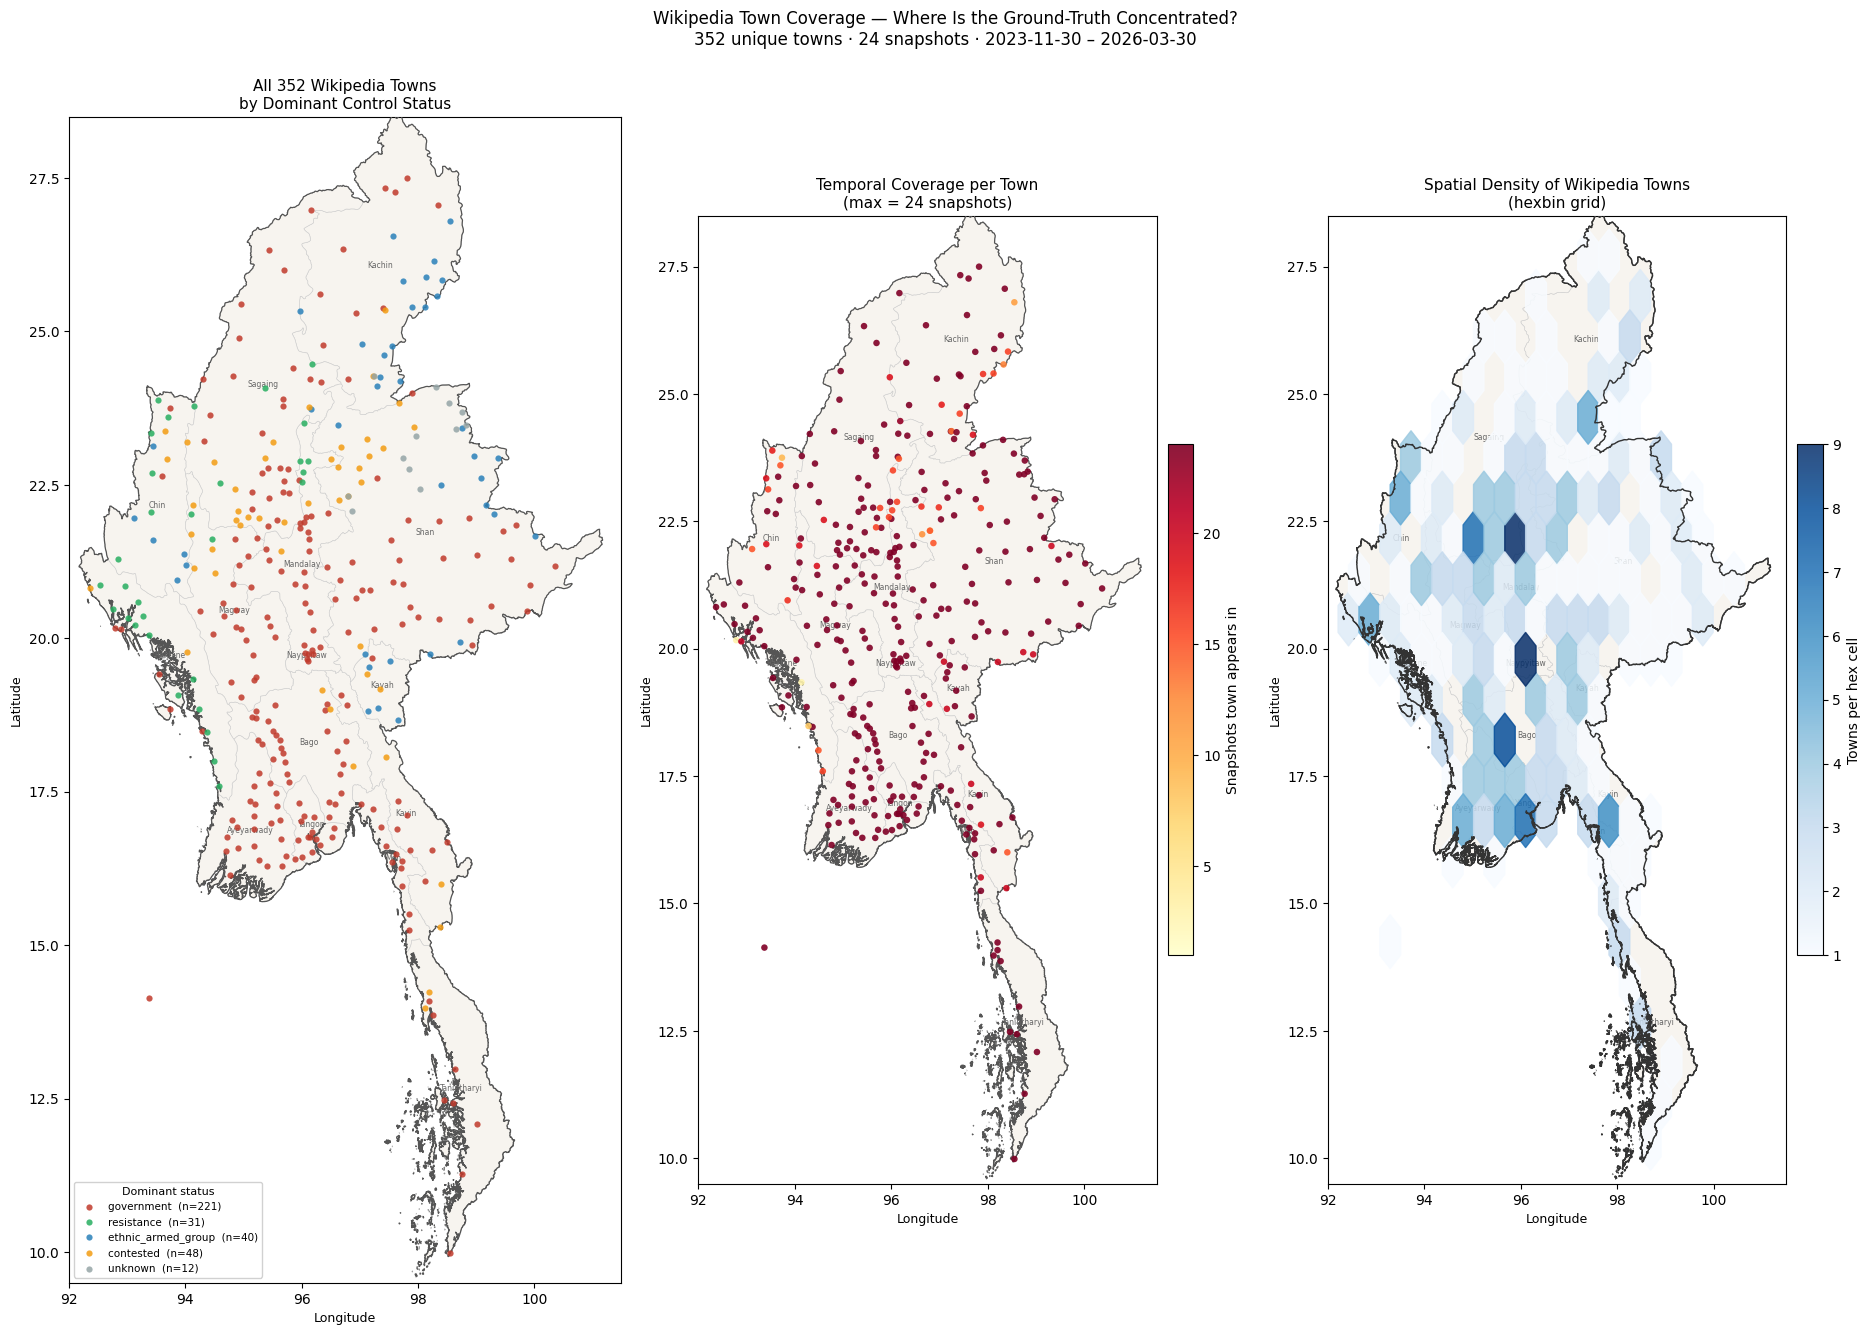

In [3]:
snap_count = (wiki.groupby(['lat', 'lon'])['date'].nunique()
              .reset_index().rename(columns={'date': 'n_snaps'}))
dom_status = (wiki.groupby(['lat', 'lon'])['control_status']
              .agg(lambda x: x.value_counts().index[0])
              .reset_index().rename(columns={'control_status': 'dom_status'}))
towns_info = (wiki.drop_duplicates(['lat', 'lon'])
              .merge(snap_count, on=['lat', 'lon'])
              .merge(dom_status, on=['lat', 'lon']))

STATUS_COLORS = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
    'unknown':            '#95a5a6',
}

fig, axes = plt.subplots(1, 3, figsize=(19, 13))

# Left: towns coloured by dominant control status
ax = axes[0]; bg(ax)
for status, col in STATUS_COLORS.items():
    sub = towns_info[towns_info['dom_status'] == status]
    if len(sub):
        ax.scatter(sub['lon'], sub['lat'], c=col, s=20, alpha=0.85,
                   linewidths=0, zorder=5, label=f'{status}  (n={len(sub)})')
ax.set_title(f'All {len(towns_info)} Wikipedia Towns\nby Dominant Control Status', fontsize=11)
ax.legend(fontsize=7.5, loc='lower left', framealpha=0.9,
          title='Dominant status', title_fontsize=8)

# Middle: temporal coverage per town
ax = axes[1]; bg(ax)
norm = mcolors.Normalize(vmin=1, vmax=towns_info['n_snaps'].max())
sc2  = ax.scatter(towns_info['lon'], towns_info['lat'],
                  c=towns_info['n_snaps'], cmap='YlOrRd',
                  norm=norm, s=22, alpha=0.9, linewidths=0, zorder=5)
fig.colorbar(sc2, ax=ax, shrink=0.42, pad=0.02, label='Snapshots town appears in')
ax.set_title(f'Temporal Coverage per Town\n(max = {towns_info["n_snaps"].max()} snapshots)', fontsize=11)

# Right: hexbin density
ax = axes[2]; bg(ax)
hb = ax.hexbin(towns_info['lon'], towns_info['lat'], gridsize=22,
               cmap='Blues', mincnt=1,
               extent=(MMR[0], MMR[2], MMR[1], MMR[3]),
               zorder=5, alpha=0.85)
gadm0.boundary.plot(ax=ax, color='#333', linewidth=1.0, zorder=6)
fig.colorbar(hb, ax=ax, shrink=0.42, pad=0.02, label='Towns per hex cell')
ax.set_title('Spatial Density of Wikipedia Towns\n(hexbin grid)', fontsize=11)

plt.suptitle(
    f'Wikipedia Town Coverage — Where Is the Ground-Truth Concentrated?\n'
    f'{len(towns_info)} unique towns · {wiki["date"].nunique()} snapshots · '
    f'{wiki["date"].min().date()} – {wiki["date"].max().date()}',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'wikipedia_town_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 1 — Distance Decay

Does agreement between ACLED gain events and Wikipedia labels drop as the event gets farther from any Wikipedia-labelled town?

**Method:** bin events by distance to nearest Wikipedia town (0–5, 5–15, 15–30, 30–50, >50 km), compute mean score and full-match rate per bin at both cell level and town level (nearest town, event+30d).

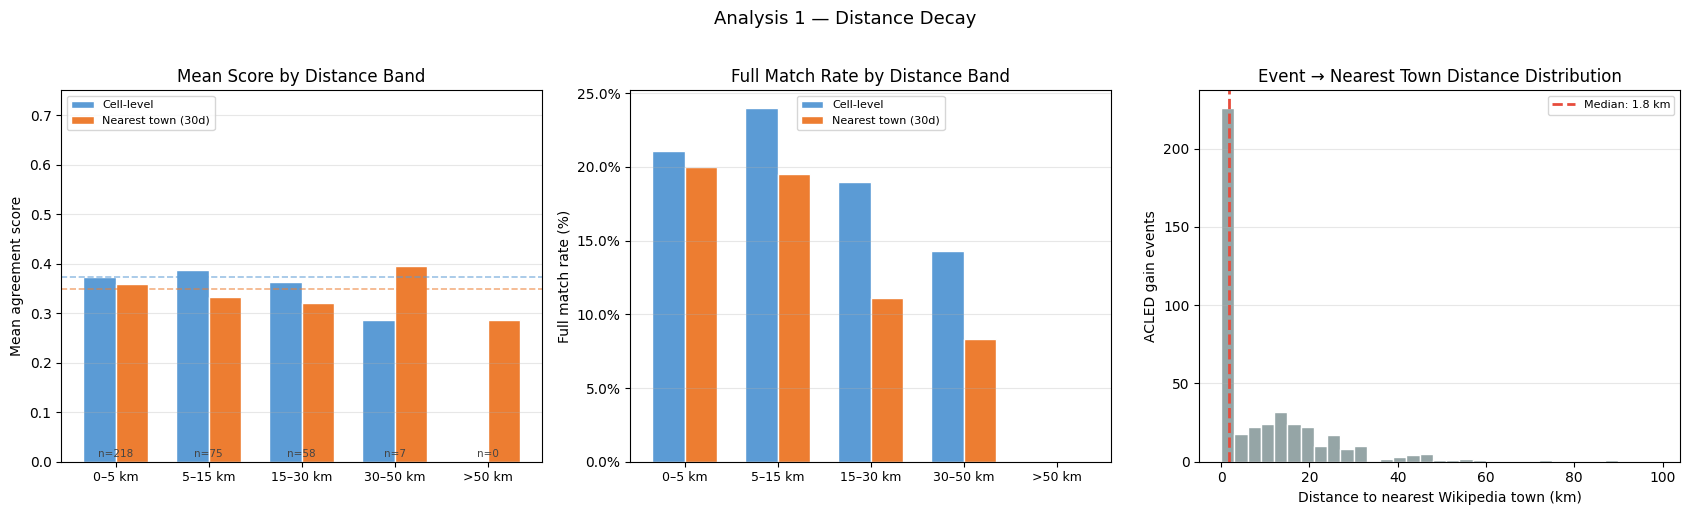

dist_bin   n  cell_mean  cell_full  town_mean  town_full
  0–5 km 218   0.373853   0.211009   0.359574   0.200000
 5–15 km  75   0.386667   0.240000   0.333333   0.195402
15–30 km  58   0.362069   0.189655   0.320988   0.111111
30–50 km   7   0.285714   0.142857   0.395833   0.083333
  >50 km   0        NaN        NaN   0.285714   0.000000


In [4]:
def score_nearest_town(i, lag_days=30):
    if nn_km[i] > 200: return np.nan
    row    = sc.iloc[i]
    target = row['event_date'] + pd.Timedelta(days=lag_days)
    ts     = town_ts.get((towns.iloc[nn_idx[i]]['lat'], towns.iloc[nn_idx[i]]['lon']), {})
    if not ts: return np.nan
    snap = min(ts.keys(), key=lambda d: abs((d - target).days))
    return score_agreement(ts[snap][0], row['expected_label'])

sc['town_score_nearest_30d'] = [score_nearest_town(i) for i in range(len(sc))]

bins       = [0, 5, 15, 30, 50, 500]
bin_labels = ['0–5 km', '5–15 km', '15–30 km', '30–50 km', '>50 km']
sc['dist_bin'] = pd.cut(sc['nearest_town_km_nn'], bins=bins, labels=bin_labels, right=False)

dist_grp = sc.groupby('dist_bin', observed=True).agg(
    n         =('cell_score_m1', 'count'),
    cell_mean =('cell_score_m1',           lambda x: x.dropna().mean()),
    cell_full =('cell_score_m1',           lambda x: (x.dropna() == 1.0).mean()),
    town_mean =('town_score_nearest_30d',  lambda x: x.dropna().mean()),
    town_full =('town_score_nearest_30d',  lambda x: (x.dropna() == 1.0).mean()),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = np.arange(len(dist_grp)); w = 0.35

ax = axes[0]
ax.bar(x - w/2, dist_grp['cell_mean'], w, color=C1, label='Cell-level', edgecolor='white')
ax.bar(x + w/2, dist_grp['town_mean'], w, color=C2, label='Nearest town (30d)', edgecolor='white')
ax.axhline(sc['cell_score_m1'].dropna().mean(),          ls='--', color=C1, lw=1.2, alpha=.6)
ax.axhline(sc['town_score_nearest_30d'].dropna().mean(), ls='--', color=C2, lw=1.2, alpha=.6)
for i, r in dist_grp.iterrows():
    ax.text(i, 0.01, f"n={r['n']}", ha='center', fontsize=7.5, color='#444')
ax.set_xticks(x); ax.set_xticklabels(dist_grp['dist_bin'], fontsize=9)
ax.set_ylabel('Mean agreement score'); ax.set_title('Mean Score by Distance Band')
ax.set_ylim(0, .75); ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)

ax = axes[1]
ax.bar(x - w/2, dist_grp['cell_full'] * 100, w, color=C1, label='Cell-level', edgecolor='white')
ax.bar(x + w/2, dist_grp['town_full'] * 100, w, color=C2, label='Nearest town (30d)', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(dist_grp['dist_bin'], fontsize=9)
ax.set_ylabel('Full match rate (%)'); ax.set_title('Full Match Rate by Distance Band')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)

ax = axes[2]
ax.hist(nn_km, bins=np.arange(0, 100, 3), color='#95A5A6', edgecolor='white')
ax.axvline(np.median(nn_km), color='#E74C3C', ls='--', lw=2,
           label=f'Median: {np.median(nn_km):.1f} km')
ax.set_xlabel('Distance to nearest Wikipedia town (km)')
ax.set_ylabel('ACLED gain events')
ax.set_title('Event → Nearest Town Distance Distribution')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)

plt.suptitle('Analysis 1 — Distance Decay', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'analysis1_distance_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print(dist_grp[['dist_bin', 'n', 'cell_mean', 'cell_full', 'town_mean', 'town_full']].to_string(index=False))

---
## Analysis 2 — Cell Homogeneity

When a PRIOGRID cell contains multiple Wikipedia-labelled towns, do they all agree? If a cell is internally inconsistent (towns disagree on who controls it), the score will be low regardless of radius.

**Method:** compute the fraction of towns sharing the majority label per cell-month (homogeneity = 1.0 means all towns agree). Look up each event's cell homogeneity at M+1 and compare agreement scores.

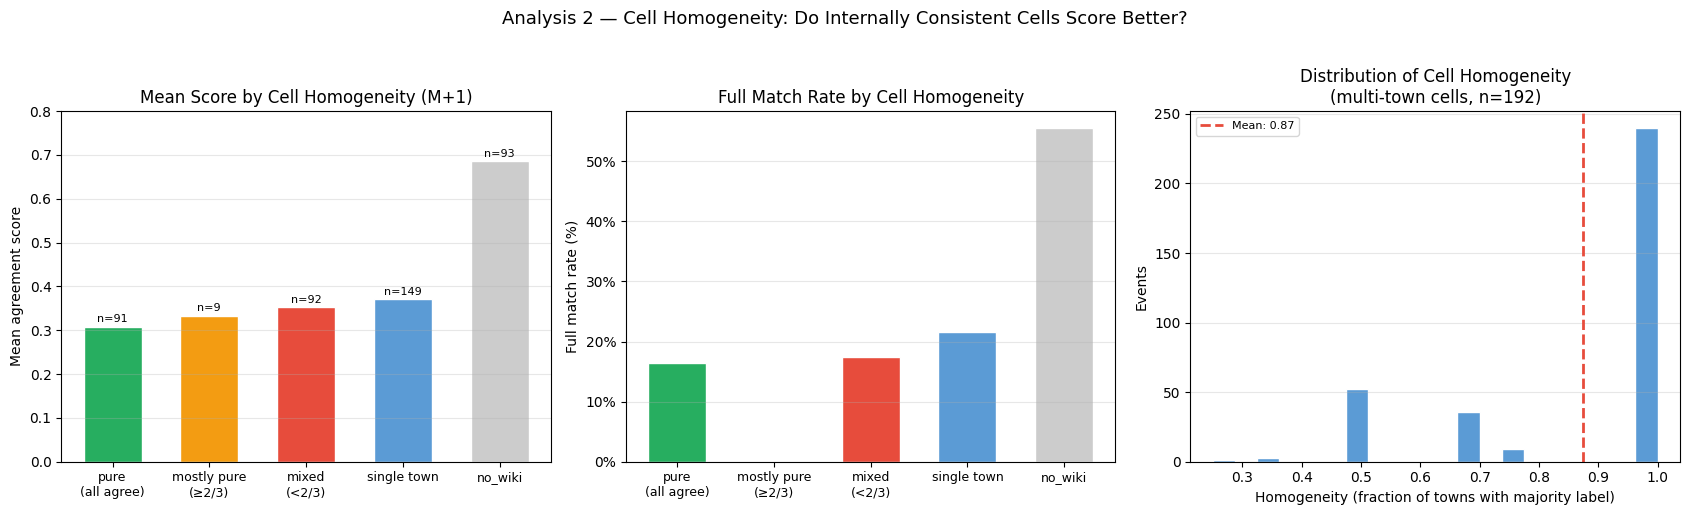

                cat  n_events  n_scored     mean     full
  pure\n(all agree)        91        91 0.307692 0.164835
mostly pure\n(≥2/3)         9         9 0.333333 0.000000
      mixed\n(<2/3)        92        92 0.353261 0.173913
        single town       149       139 0.370504 0.215827
            no_wiki        93        27 0.685185 0.555556


In [5]:
def homogeneity(labels):
    ls = [l for l in labels if pd.notna(l)]
    if not ls: return np.nan
    return Counter(ls).most_common(1)[0][1] / len(ls)

cell_hom = (wiki.groupby(['priogrid_gid', 'year_month'])['control_status']
            .agg([('hom', homogeneity), ('n_towns', 'count')])
            .reset_index())
hom_lkup = cell_hom.set_index(['priogrid_gid', 'year_month'])[['hom', 'n_towns']].to_dict('index')

def get_hom(gid, ym, lag=1):
    t = str(pd.Period(ym, 'M') + lag)
    r = hom_lkup.get((gid, t), {})
    return r.get('hom', np.nan), r.get('n_towns', 0)

sc['cell_hom'], sc['cell_ntowns'] = zip(
    *sc.apply(lambda r: get_hom(r['priogrid_gid'], r['year_month']), axis=1))

def hom_cat(h, n):
    if pd.isna(h) or n == 0:   return 'no_wiki'
    if n == 1:                  return 'single town'
    if h == 1.0:                return 'pure\n(all agree)'
    if h >= 0.67:               return 'mostly pure\n(≥2/3)'
    return                             'mixed\n(<2/3)'

sc['hom_cat'] = sc.apply(lambda r: hom_cat(r['cell_hom'], r['cell_ntowns']), axis=1)

CAT_ORDER  = ['pure\n(all agree)', 'mostly pure\n(≥2/3)', 'mixed\n(<2/3)', 'single town', 'no_wiki']
CAT_COLORS = {'pure\n(all agree)': '#27AE60', 'mostly pure\n(≥2/3)': '#F39C12',
              'mixed\n(<2/3)': '#E74C3C',     'single town': '#5B9BD5', 'no_wiki': '#CCCCCC'}

valid_cats = [c for c in CAT_ORDER if c in sc['hom_cat'].values]
stats = []
for cat in valid_cats:
    sub = sc.loc[sc['hom_cat'] == cat, 'cell_score_m1'].dropna()
    stats.append({'cat': cat, 'n_events': len(sc[sc['hom_cat'] == cat]),
                  'n_scored': len(sub),
                  'mean': sub.mean() if len(sub) else np.nan,
                  'full': (sub == 1.0).mean() if len(sub) else np.nan})
stat_df = pd.DataFrame(stats)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x2 = np.arange(len(stat_df))

ax = axes[0]
ax.bar(x2, stat_df['mean'].fillna(0), color=[CAT_COLORS[c] for c in stat_df['cat']],
       edgecolor='white', width=.6)
for i, r in stat_df.iterrows():
    if not pd.isna(r['mean']):
        ax.text(i, r['mean'] + .01, f"n={r['n_events']}", ha='center', fontsize=8)
ax.set_xticks(x2); ax.set_xticklabels(stat_df['cat'], fontsize=9)
ax.set_ylabel('Mean agreement score'); ax.set_title('Mean Score by Cell Homogeneity (M+1)')
ax.set_ylim(0, .8); ax.grid(axis='y', alpha=.3)

ax = axes[1]
ax.bar(x2, stat_df['full'].fillna(0) * 100,
       color=[CAT_COLORS[c] for c in stat_df['cat']], edgecolor='white', width=.6)
ax.set_xticks(x2); ax.set_xticklabels(stat_df['cat'], fontsize=9)
ax.set_ylabel('Full match rate (%)'); ax.set_title('Full Match Rate by Cell Homogeneity')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis='y', alpha=.3)

ax = axes[2]
hv = sc['cell_hom'].dropna()
n_multi = (sc['cell_ntowns'] > 1).sum()
ax.hist(hv, bins=20, color=C1, edgecolor='white')
ax.axvline(hv.mean(), color='#E74C3C', ls='--', lw=2, label=f'Mean: {hv.mean():.2f}')
ax.set_xlabel('Homogeneity (fraction of towns with majority label)')
ax.set_ylabel('Events')
ax.set_title(f'Distribution of Cell Homogeneity\n(multi-town cells, n={n_multi})')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)

plt.suptitle('Analysis 2 — Cell Homogeneity: Do Internally Consistent Cells Score Better?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'analysis2_cell_homogeneity.png', dpi=150, bbox_inches='tight')
plt.show()
print(stat_df[['cat', 'n_events', 'n_scored', 'mean', 'full']].to_string(index=False))

---
## Analysis 3 — Temporal Lag Sensitivity

Wikipedia is updated manually and irregularly. An event in January may not appear in the Wikipedia map until March. Does the agreement score improve if we look at later snapshots?

**Method:** score each event against Wikipedia at lag 0, +14, +30, +60, +90 days (town-level, nearest town ≤50 km) and at month offsets M+0, M+1, M+2, M+3 (cell-level).

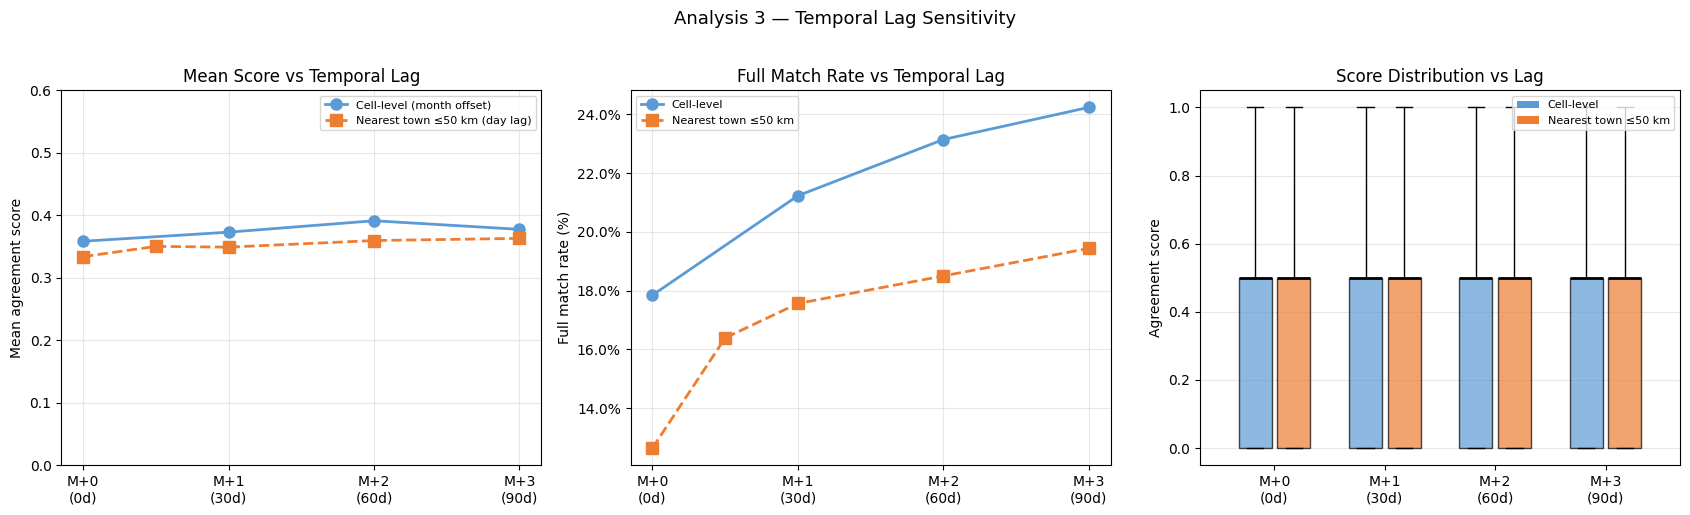

Cell-level mean scores by lag:
  M+0: mean=0.358  full=17.8%  (n=353)
  M+1: mean=0.373  full=21.2%  (n=358)
  M+2: mean=0.391  full=23.1%  (n=363)
  M+3: mean=0.377  full=24.2%  (n=359)

Town-level (≤50 km) mean scores by lag:
  + 0d: mean=0.334  full=12.6%  (n=427)
  +14d: mean=0.350  full=16.4%  (n=427)
  +30d: mean=0.349  full=17.6%  (n=427)
  +60d: mean=0.359  full=18.5%  (n=427)
  +90d: mean=0.363  full=19.4%  (n=427)


In [6]:
LAGS_DAYS   = [0, 14, 30, 60, 90]
LAG_MONTHS  = [0, 1, 2, 3]
APPROX_M    = {0: 0, 14: .5, 30: 1, 60: 2, 90: 3}

# Cell-level at month offsets
for lag_m in LAG_MONTHS:
    col = f'cell_score_m{lag_m}'
    if col not in sc.columns:
        sc[col] = sc.apply(
            lambda r, l=lag_m: score_agreement(
                cell_lkup.get((r['priogrid_gid'], str(pd.Period(r['year_month'], 'M') + l)), np.nan),
                r['expected_label']), axis=1)

# Town-level: nearest town ≤50 km at each day lag
for lag_d in LAGS_DAYS:
    col = f'lag{lag_d}_town50'
    scores = []
    for i in range(len(sc)):
        if nn_km[i] > 50:
            scores.append(np.nan); continue
        row    = sc.iloc[i]
        target = row['event_date'] + pd.Timedelta(days=lag_d)
        ts     = town_ts.get((towns.iloc[nn_idx[i]]['lat'], towns.iloc[nn_idx[i]]['lon']), {})
        if not ts:
            scores.append(np.nan); continue
        snap = min(ts.keys(), key=lambda d: abs((d - target).days))
        scores.append(score_agreement(ts[snap][0], row['expected_label']))
    sc[col] = scores

cell_mean_lag = [sc[f'cell_score_m{l}'].dropna().mean() for l in LAG_MONTHS]
cell_full_lag = [(sc[f'cell_score_m{l}'].dropna() == 1.0).mean() for l in LAG_MONTHS]
town_mean_lag = [sc[f'lag{l}_town50'].dropna().mean() for l in LAGS_DAYS]
town_full_lag = [(sc[f'lag{l}_town50'].dropna() == 1.0).mean() for l in LAGS_DAYS]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
tick_labels = ['M+0\n(0d)', 'M+1\n(30d)', 'M+2\n(60d)', 'M+3\n(90d)']

ax = axes[0]
ax.plot(LAG_MONTHS, cell_mean_lag, 'o-', color=C1, lw=2, ms=8, label='Cell-level (month offset)')
ax.plot([APPROX_M[l] for l in LAGS_DAYS], town_mean_lag, 's--', color=C2, lw=2, ms=8,
        label='Nearest town ≤50 km (day lag)')
ax.set_xticks(LAG_MONTHS); ax.set_xticklabels(tick_labels)
ax.set_ylabel('Mean agreement score'); ax.set_title('Mean Score vs Temporal Lag')
ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, .6)

ax = axes[1]
ax.plot(LAG_MONTHS, [f * 100 for f in cell_full_lag], 'o-', color=C1, lw=2, ms=8, label='Cell-level')
ax.plot([APPROX_M[l] for l in LAGS_DAYS], [f * 100 for f in town_full_lag], 's--', color=C2, lw=2, ms=8,
        label='Nearest town ≤50 km')
ax.set_xticks(LAG_MONTHS); ax.set_xticklabels(tick_labels)
ax.set_ylabel('Full match rate (%)'); ax.set_title('Full Match Rate vs Temporal Lag')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[2]
data_cell = [sc[f'cell_score_m{l}'].dropna().values for l in LAG_MONTHS]
data_town = [sc[f'lag{l}_town50'].dropna().values   for l in LAGS_DAYS[:4]]
pos_c = [0, 1, 2, 3]; pos_t = [v + .35 for v in pos_c]
bp1 = ax.boxplot(data_cell, positions=pos_c, widths=.3, patch_artist=True,
                 boxprops=dict(facecolor=C1, alpha=.7),
                 medianprops=dict(color='black', lw=2),
                 flierprops=dict(marker='.', ms=3))
bp2 = ax.boxplot(data_town, positions=pos_t, widths=.3, patch_artist=True,
                 boxprops=dict(facecolor=C2, alpha=.7),
                 medianprops=dict(color='black', lw=2),
                 flierprops=dict(marker='.', ms=3))
ax.set_xticks([v + .175 for v in pos_c]); ax.set_xticklabels(tick_labels)
ax.set_ylabel('Agreement score'); ax.set_title('Score Distribution vs Lag')
ax.legend([mpatches.Patch(facecolor=C1), mpatches.Patch(facecolor=C2)],
          ['Cell-level', 'Nearest town ≤50 km'], fontsize=8)
ax.grid(axis='y', alpha=.3)

plt.suptitle('Analysis 3 — Temporal Lag Sensitivity', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'analysis3_temporal_lag.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cell-level mean scores by lag:')
for l, m, f in zip(LAG_MONTHS, cell_mean_lag, cell_full_lag):
    print(f'  M+{l}: mean={m:.3f}  full={f:.1%}  (n={sc[f"cell_score_m{l}"].notna().sum()})')
print('\nTown-level (≤50 km) mean scores by lag:')
for l, m, f in zip(LAGS_DAYS, town_mean_lag, town_full_lag):
    print(f'  +{l:2d}d: mean={m:.3f}  full={f:.1%}  (n={sc[f"lag{l}_town50"].notna().sum()})')

---
## Analysis 4 — Sub-Event Type × Actor Breakdown

The 4 ACLED territorial control sub-event types capture different dynamics. Are some systematically better verified by Wikipedia than others? And does the actor matter?

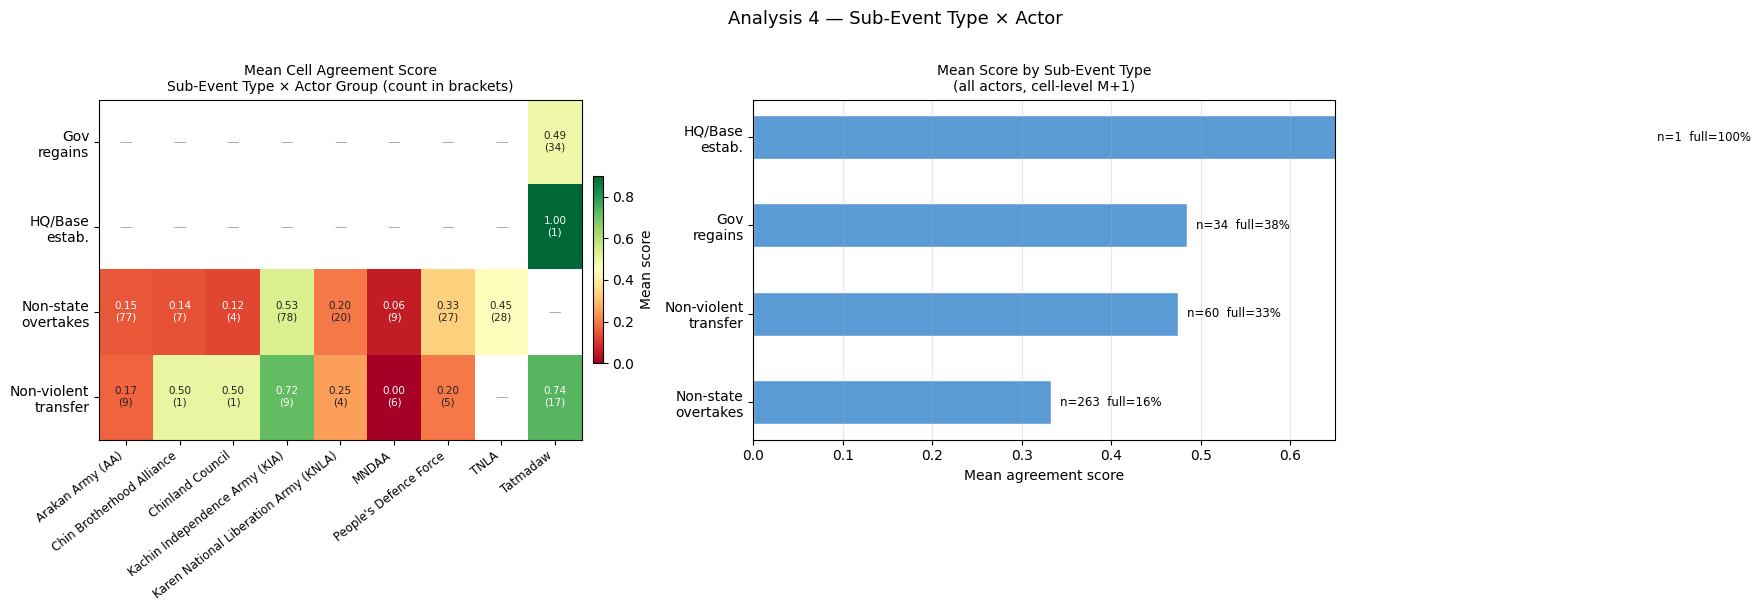

            sub_short  count     mean     full
 Non-state\novertakes    263 0.332700 0.159696
Non-violent\ntransfer     60 0.475000 0.333333
         Gov\nregains     34 0.485294 0.382353
      HQ/Base\nestab.      1 1.000000 1.000000


In [7]:
SUB_MAP = {
    'Non-state actor overtakes territory': 'Non-state\novertakes',
    'Government regains territory':        'Gov\nregains',
    'Non-violent transfer of territory':   'Non-violent\ntransfer',
    'Headquarters or base established':    'HQ/Base\nestab.',
}
sc['sub_short'] = sc['sub_event_type'].map(SUB_MAP).fillna(sc['sub_event_type'])

top_actors = sc['actor_group'].value_counts().head(9).index.tolist()
sc_top     = sc[sc['actor_group'].isin(top_actors)]

pivot_m = sc_top.pivot_table('cell_score_m1', 'sub_short', 'actor_group', aggfunc='mean')
pivot_n = sc_top.pivot_table('cell_score_m1', 'sub_short', 'actor_group', aggfunc='count')

sub_stats = (sc.groupby('sub_short')['cell_score_m1']
             .agg(mean='mean', count='count',
                  full=lambda x: (x.dropna() == 1.0).mean())
             .reset_index().sort_values('mean', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
im = ax.imshow(pivot_m.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.9, interpolation='none')
ax.set_xticks(range(len(pivot_m.columns)))
ax.set_xticklabels(pivot_m.columns, rotation=38, ha='right', fontsize=8.5)
ax.set_yticks(range(len(pivot_m.index)))
ax.set_yticklabels(pivot_m.index, fontsize=10)
for i in range(len(pivot_m.index)):
    for j in range(len(pivot_m.columns)):
        v = pivot_m.values[i, j]; n = pivot_n.values[i, j]
        if not np.isnan(v):
            c = 'white' if (v > .65 or v < .15) else '#222'
            ax.text(j, i, f'{v:.2f}\n({int(n)})', ha='center', va='center', fontsize=7.5, color=c)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='#aaa')
plt.colorbar(im, ax=ax, shrink=.55, pad=.02, label='Mean score')
ax.set_title('Mean Cell Agreement Score\nSub-Event Type × Actor Group (count in brackets)', fontsize=10)

ax = axes[1]
y4 = np.arange(len(sub_stats))
ax.barh(y4, sub_stats['mean'], .5, color=C1, label='Mean score', edgecolor='white')
ax.set_yticks(y4); ax.set_yticklabels(sub_stats['sub_short'], fontsize=10)
ax.set_xlabel('Mean agreement score')
ax.set_title('Mean Score by Sub-Event Type\n(all actors, cell-level M+1)', fontsize=10)
ax.grid(axis='x', alpha=.3); ax.set_xlim(0, .65)
for i, r in sub_stats.reset_index().iterrows():
    ax.text(r['mean'] + .01, i, f"n={int(r['count'])}  full={r['full']:.0%}",
            va='center', fontsize=8.5)

plt.suptitle('Analysis 4 — Sub-Event Type × Actor', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'analysis4_subtype_actor.png', dpi=150, bbox_inches='tight')
plt.show()
print(sub_stats[['sub_short', 'count', 'mean', 'full']].to_string(index=False))

---
## Analysis 5 — Admin1 Regional Breakdown

Agreement likely clusters geographically. This analysis breaks scores down by Myanmar state/region and plots a choropleth map.

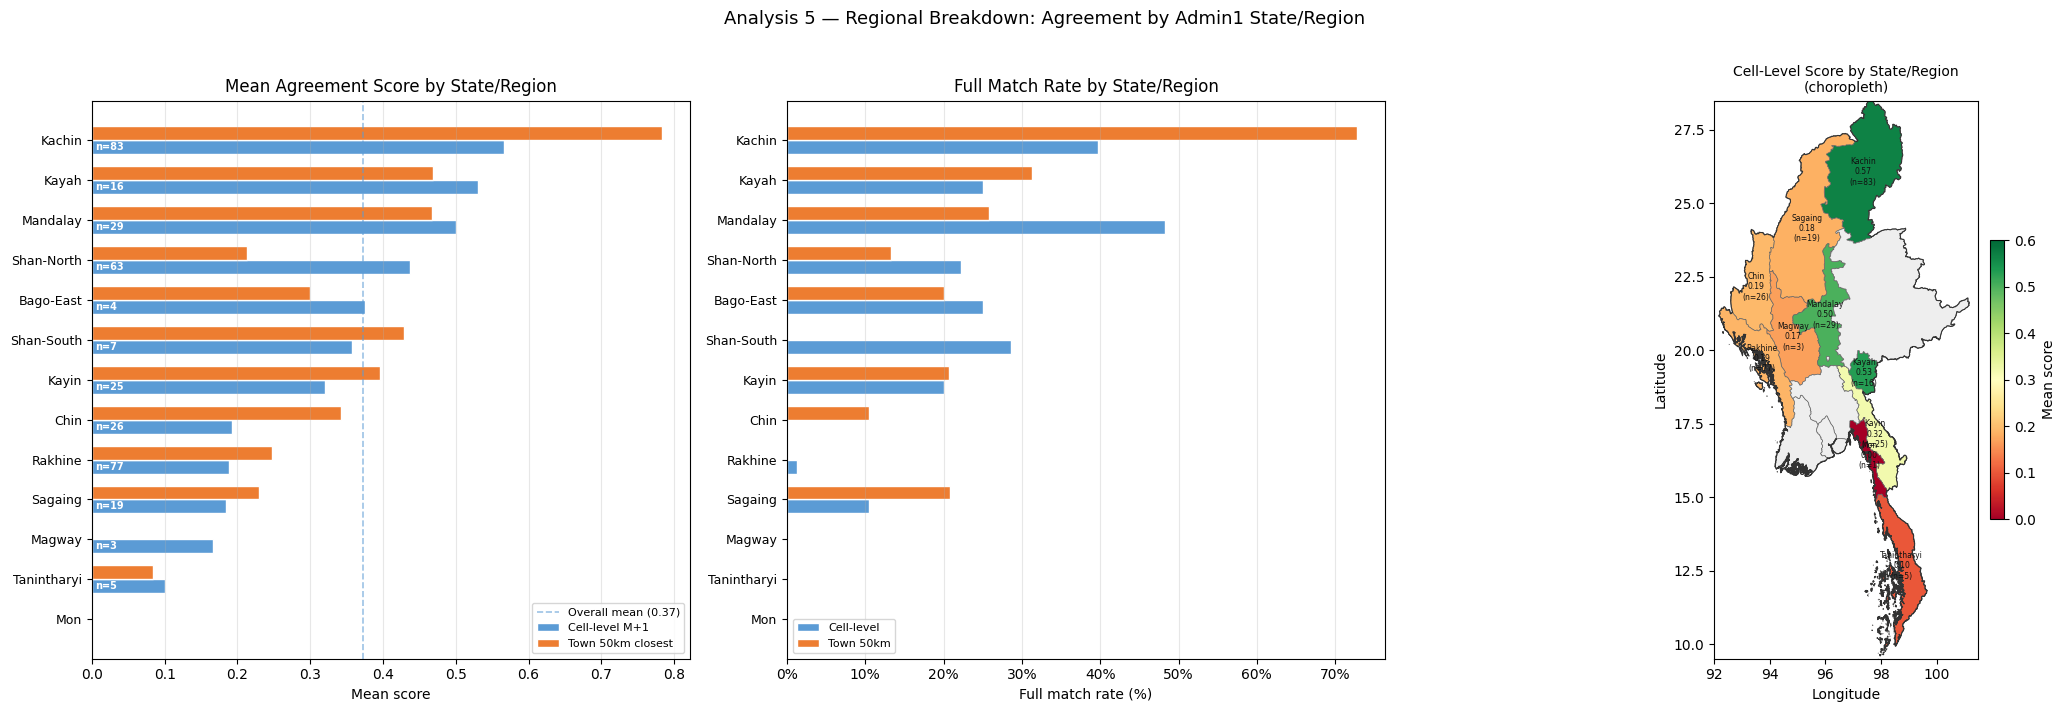

     admin1  n  cell_mean  cell_full  town_mean
        Mon  1   0.000000   0.000000   0.000000
Tanintharyi  5   0.100000   0.000000   0.083333
     Magway  3   0.166667   0.000000   0.000000
    Sagaing 19   0.184211   0.105263   0.229167
    Rakhine 77   0.188312   0.012987   0.247312
       Chin 26   0.192308   0.000000   0.342105
      Kayin 25   0.320000   0.200000   0.396552
 Shan-South  7   0.357143   0.285714   0.428571
  Bago-East  4   0.375000   0.250000   0.300000
 Shan-North 63   0.436508   0.222222   0.213333
   Mandalay 29   0.500000   0.482759   0.467742
      Kayah 16   0.531250   0.250000   0.468750
     Kachin 83   0.566265   0.397590   0.782828


In [8]:
a1 = (sc.groupby('admin1').agg(
    n          =('cell_score_m1', 'count'),
    cell_mean  =('cell_score_m1',      lambda x: x.dropna().mean()),
    cell_full  =('cell_score_m1',      lambda x: (x.dropna() == 1.0).mean()),
    town_mean  =('r50_closest_score',  lambda x: x.dropna().mean()),
    town_full  =('r50_closest_score',  lambda x: (x.dropna() == 1.0).mean()),
).reset_index().sort_values('cell_mean', ascending=True))

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
y5 = np.arange(len(a1)); w5 = .35

ax = axes[0]
ax.barh(y5 - w5/2, a1['cell_mean'],             w5, color=C1, label='Cell-level M+1',    edgecolor='white')
ax.barh(y5 + w5/2, a1['town_mean'].fillna(0),   w5, color=C2, label='Town 50km closest', edgecolor='white')
ax.set_yticks(y5); ax.set_yticklabels(a1['admin1'], fontsize=9)
ax.set_xlabel('Mean score'); ax.set_title('Mean Agreement Score by State/Region')
ax.axvline(sc['cell_score_m1'].dropna().mean(), ls='--', color=C1, lw=1.2, alpha=.6,
           label=f'Overall mean ({sc["cell_score_m1"].dropna().mean():.2f})')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=.3)
for i, r in a1.reset_index().iterrows():
    ax.text(0.005, i - w5/2, f"n={r['n']}", va='center', fontsize=7,
            color='white', fontweight='bold')

ax = axes[1]
ax.barh(y5 - w5/2, a1['cell_full'] * 100,           w5, color=C1, label='Cell-level', edgecolor='white')
ax.barh(y5 + w5/2, a1['town_full'].fillna(0) * 100, w5, color=C2, label='Town 50km',  edgecolor='white')
ax.set_yticks(y5); ax.set_yticklabels(a1['admin1'], fontsize=9)
ax.set_xlabel('Full match rate (%)'); ax.set_title('Full Match Rate by State/Region')
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=8); ax.grid(axis='x', alpha=.3)

ax = axes[2]
gdf = gadm1[['NAME_1', 'geometry']].merge(
    a1[['admin1', 'cell_mean', 'n']].rename(columns={'admin1': 'NAME_1'}),
    on='NAME_1', how='left')
gdf.plot(column='cell_mean', ax=ax, cmap='RdYlGn', vmin=0, vmax=.6,
         edgecolor='#666', linewidth=.5,
         missing_kwds={'color': '#EEE', 'label': 'No events'},
         legend=True, legend_kwds={'label': 'Mean score', 'shrink': .5, 'pad': .02})
gadm0.boundary.plot(ax=ax, color='#333', linewidth=.8)
for _, row in gdf.iterrows():
    if pd.notna(row.get('cell_mean')):
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy, f"{row['NAME_1']}\n{row['cell_mean']:.2f}\n(n={int(row['n'])})",
                ha='center', va='center', fontsize=5.5, color='#111')
ax.set_xlim(MMR[0], MMR[2]); ax.set_ylim(MMR[1], MMR[3])
ax.set_title('Cell-Level Score by State/Region\n(choropleth)', fontsize=10)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle('Analysis 5 — Regional Breakdown: Agreement by Admin1 State/Region',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'analysis5_admin1.png', dpi=150, bbox_inches='tight')
plt.show()
print(a1[['admin1', 'n', 'cell_mean', 'cell_full', 'town_mean']].to_string(index=False))

---
## Analysis 6 — Control Cell Turnover at PRIOGRID Resolution

How often do Wikipedia-labelled cells actually change their control status? This measures the *dynamics* of the ground-truth itself — independent of ACLED.

**Sub-analyses:**
- **6a** Monthly change rate: % of cells flipping label each snapshot
- **6b** Transition matrix: which status transitions to which?
- **6c** Duration distribution: how long (months) does a cell stay under one label?
- **6d** Stability by status: which control status is most persistent?
- **6e** Map of volatile cells: where do the most changes happen?

**Note:** LOCF months (is_direct_snapshot=False) carry forward the previous label, so transitions can only occur on direct snapshot months.

In [9]:
# ── load and sort cell labels ─────────────────────────────────────────────────
cells = pd.read_csv(ROOT / 'data/processed/myanmar_priogrid_labels.csv')
cells['year_month'] = cells['year_month'].astype(str)
cells = cells.sort_values(['priogrid_gid', 'year_month']).reset_index(drop=True)

# ── detect transitions ────────────────────────────────────────────────────────
cells['prev_status'] = cells.groupby('priogrid_gid')['control_status'].shift(1)
cells['is_change']   = (
    cells['control_status'] != cells['prev_status']
) & cells['prev_status'].notna()

# transition label  e.g. "government → resistance"
cells['transition'] = cells.apply(
    lambda r: f"{r['prev_status']} → {r['control_status']}"
    if r['is_change'] else None, axis=1)

n_cells   = cells['priogrid_gid'].nunique()
n_months  = cells['year_month'].nunique()
n_changes = cells['is_change'].sum()

print(f'Cells:   {n_cells}')
print(f'Months:  {n_months}  ({cells["year_month"].min()} – {cells["year_month"].max()})')
print(f'Total cell-months: {len(cells):,}')
print(f'Total transitions: {n_changes}  ({n_changes / len(cells):.1%} of cell-months)')
print()
print('Top transitions:')
print(cells.loc[cells['is_change'], 'transition'].value_counts().head(15).to_string())

Cells:   185
Months:  29  (2023-11 – 2026-03)
Total cell-months: 5,238
Total transitions: 101  (1.9% of cell-months)

Top transitions:
transition
contested → government             41
government → ethnic_armed_group    17
government → contested             12
contested → resistance              9
government → resistance             7
contested → ethnic_armed_group      7
ethnic_armed_group → government     5
resistance → government             2
ethnic_armed_group → contested      1


In [10]:
# ── 6a: monthly change rate ───────────────────────────────────────────────────
monthly = (cells.groupby('year_month')
           .agg(n_cells_with_data =('priogrid_gid', 'nunique'),
                n_changes         =('is_change',    'sum'),
                n_direct          =('is_direct_snapshot', 'sum'))
           .reset_index())
monthly['change_rate'] = monthly['n_changes'] / monthly['n_cells_with_data']
monthly['ym_dt'] = pd.to_datetime(monthly['year_month'] + '-01')

# ── 6b: transition matrix ─────────────────────────────────────────────────────
statuses = ['government', 'resistance', 'ethnic_armed_group', 'contested']
trans_df  = cells[cells['is_change']].copy()
trans_mat = pd.crosstab(trans_df['prev_status'], trans_df['control_status'],
                        rownames=['From'], colnames=['To'])
for s in statuses:
    if s not in trans_mat.index:   trans_mat.loc[s]  = 0
    if s not in trans_mat.columns: trans_mat[s]       = 0
trans_mat = trans_mat.reindex(index=statuses, columns=statuses, fill_value=0)

# ── 6c: duration spells ───────────────────────────────────────────────────────
# for each cell, identify consecutive runs of the same status
cells['spell_id'] = (cells.groupby('priogrid_gid')['is_change']
                     .transform(lambda x: x.cumsum()))
spell_durations = (cells.groupby(['priogrid_gid', 'spell_id', 'control_status'])
                   .size().reset_index(name='duration_months'))

# ── 6d: stability by status ────────────────────────────────────────────────────
# fraction of cell-months where the label did NOT change from previous month
stability = cells[cells['prev_status'].notna()].groupby('control_status').agg(
    n_cell_months =('is_change', 'count'),
    n_stable      =('is_change', lambda x: (~x).sum()),
).reset_index()
stability['stability_rate'] = stability['n_stable'] / stability['n_cell_months']

# ── 6e: per-cell change count ─────────────────────────────────────────────────
cell_changes = (cells.groupby('priogrid_gid')['is_change'].sum()
                .reset_index(name='n_changes'))

def gid_to_centroid(gid):
    row = (gid - 1) // 720; col = (gid - 1) % 720
    return col * 0.5 - 180 + 0.25, row * 0.5 - 90 + 0.25   # lon, lat centres

cell_changes['lon'], cell_changes['lat'] = zip(
    *cell_changes['priogrid_gid'].apply(gid_to_centroid))

print('Duration spell stats (months):')
print(spell_durations.groupby('control_status')['duration_months']
      .describe().round(1).to_string())
print()
print('Stability by status:')
print(stability[['control_status','n_cell_months','n_stable','stability_rate']].to_string(index=False))

Duration spell stats (months):
                    count  mean  std  min   25%   50%   75%   max
control_status                                                   
contested            76.0  11.7  9.9  1.0   3.8   9.0  16.2  29.0
ethnic_armed_group   33.0  18.6  7.9  1.0  16.0  22.0  24.0  26.0
government          155.0  21.4  9.8  1.0  18.5  29.0  29.0  29.0
resistance           22.0  18.7  7.2  3.0  16.2  20.5  24.0  28.0

Stability by status:
    control_status  n_cell_months  n_stable  stability_rate
         contested            828       815        0.984300
ethnic_armed_group            604       580        0.960265
        government           3216      3168        0.985075
        resistance            405       389        0.960494


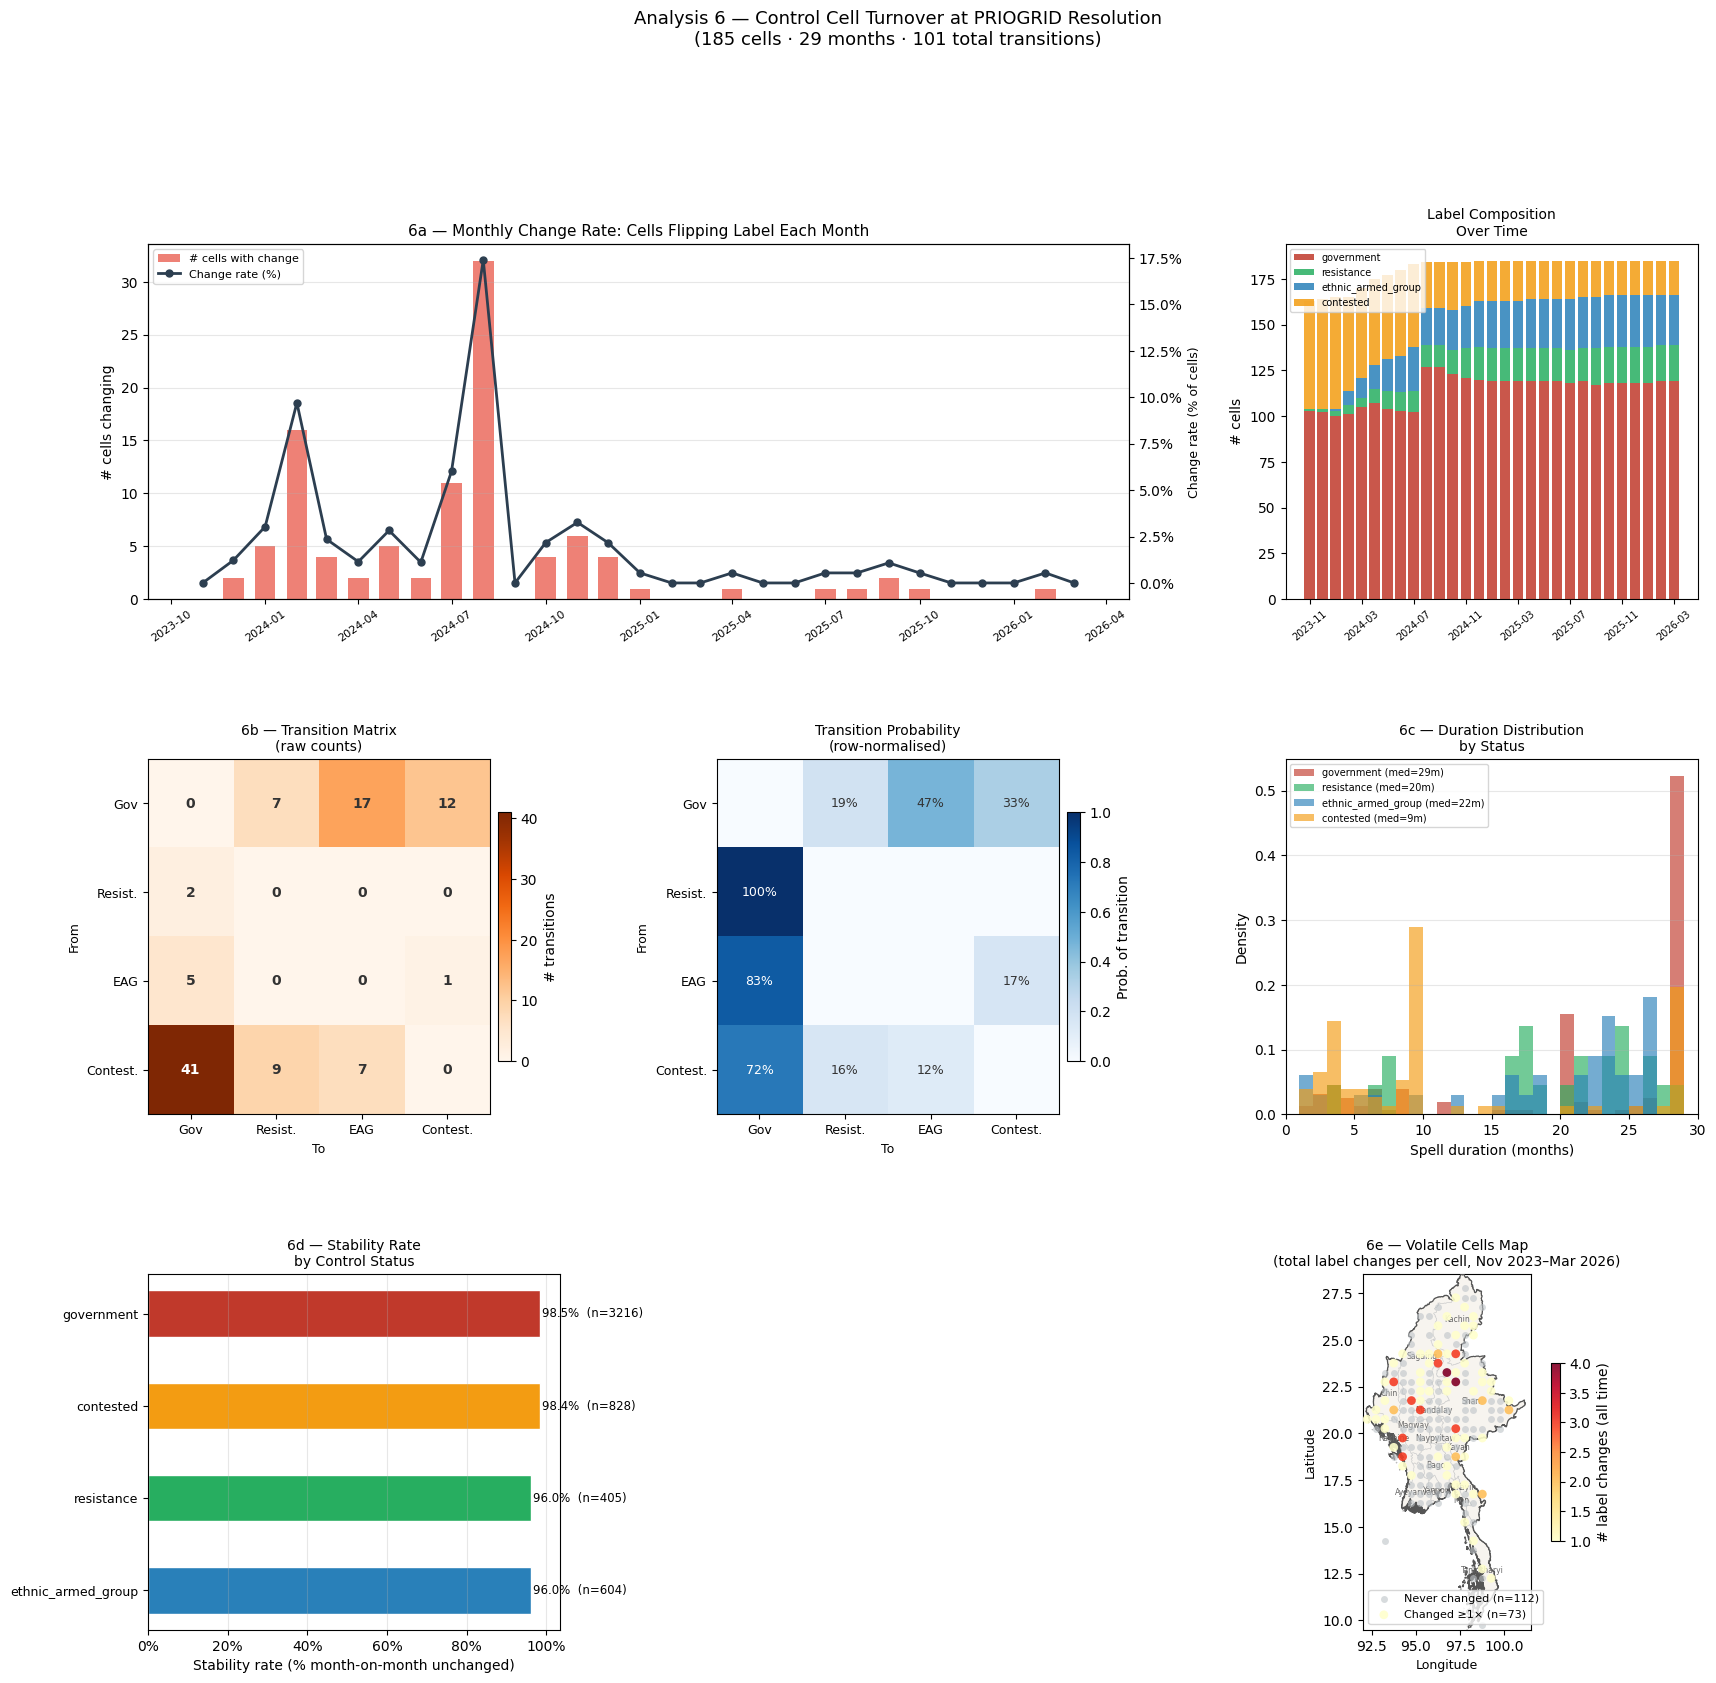


Overall:  101 transitions across 185 cells over 29 months
Avg transitions per cell: 0.5
Cells that never changed: 112 (60.5%)
Cells that changed ≥3×:   10 (5.4%)


In [11]:
STATUS_PAL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}

fig = plt.figure(figsize=(20, 18))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)

# ── 6a: monthly change rate time series ───────────────────────────────────────
ax = fig.add_subplot(gs[0, :2])
ax.bar(monthly['ym_dt'], monthly['n_changes'], color='#E74C3C', alpha=0.7,
       label='# cells with change', width=20)
ax2 = ax.twinx()
ax2.plot(monthly['ym_dt'], monthly['change_rate'] * 100,
         'o-', color='#2C3E50', lw=2, ms=5, label='Change rate (%)')
ax2.set_ylabel('Change rate (% of cells)', fontsize=9)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('# cells changing'); ax.set_xlabel('')
ax.set_title('6a — Monthly Change Rate: Cells Flipping Label Each Month', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=.3)

# ── label composition stacked area ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
status_over_time = (cells.groupby(['year_month', 'control_status'])
                    .size().unstack(fill_value=0))
status_over_time = status_over_time.reindex(columns=statuses, fill_value=0)
ym_order = sorted(status_over_time.index)
status_over_time = status_over_time.loc[ym_order]
ym_x = range(len(ym_order))
bottom = np.zeros(len(ym_order))
for s in statuses:
    vals = status_over_time[s].values
    ax.bar(ym_x, vals, bottom=bottom, label=s,
           color=STATUS_PAL.get(s, '#999'), edgecolor='none', alpha=0.85)
    bottom += vals
ax.set_xticks(ym_x[::4]); ax.set_xticklabels(ym_order[::4], rotation=40, fontsize=7)
ax.set_ylabel('# cells'); ax.set_title('Label Composition\nOver Time', fontsize=10)
ax.legend(fontsize=7, loc='upper left')

# ── 6b: transition matrix heatmap ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
short = {'government': 'Gov', 'resistance': 'Resist.', 'ethnic_armed_group': 'EAG', 'contested': 'Contest.'}
mat   = trans_mat.rename(index=short, columns=short)
im    = ax.imshow(mat.values, cmap='Oranges', aspect='auto', interpolation='none')
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, fontsize=9)
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index,    fontsize=9)
ax.set_xlabel('To', fontsize=9); ax.set_ylabel('From', fontsize=9)
for i in range(len(mat.index)):
    for j in range(len(mat.columns)):
        v = mat.values[i, j]
        c = 'white' if v > mat.values.max() * 0.5 else '#333'
        ax.text(j, i, str(int(v)), ha='center', va='center', fontsize=10, fontweight='bold', color=c)
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label='# transitions')
ax.set_title('6b — Transition Matrix\n(raw counts)', fontsize=10)

# ── row-normalised transition matrix (probability) ───────────────────────────
ax = fig.add_subplot(gs[1, 1])
row_sums = trans_mat.sum(axis=1).replace(0, np.nan)
trans_prob = trans_mat.div(row_sums, axis=0).fillna(0)
mat_p = trans_prob.rename(index=short, columns=short)
im2   = ax.imshow(mat_p.values, cmap='Blues', aspect='auto', vmin=0, vmax=1, interpolation='none')
ax.set_xticks(range(len(mat_p.columns))); ax.set_xticklabels(mat_p.columns, fontsize=9)
ax.set_yticks(range(len(mat_p.index)));   ax.set_yticklabels(mat_p.index,    fontsize=9)
ax.set_xlabel('To', fontsize=9); ax.set_ylabel('From', fontsize=9)
for i in range(len(mat_p.index)):
    for j in range(len(mat_p.columns)):
        v = mat_p.values[i, j]
        if v > 0:
            c = 'white' if v > 0.5 else '#333'
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color=c)
plt.colorbar(im2, ax=ax, shrink=0.7, pad=0.02, label='Prob. of transition')
ax.set_title('Transition Probability\n(row-normalised)', fontsize=10)

# ── 6c: duration distribution ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for s in statuses:
    sub = spell_durations[spell_durations['control_status'] == s]['duration_months']
    ax.hist(sub, bins=range(1, 30), alpha=0.65,
            color=STATUS_PAL.get(s, '#999'),
            label=f'{s} (med={sub.median():.0f}m)', density=True)
ax.set_xlabel('Spell duration (months)')
ax.set_ylabel('Density')
ax.set_title('6c — Duration Distribution\nby Status', fontsize=10)
ax.legend(fontsize=7); ax.grid(axis='y', alpha=.3)
ax.set_xlim(0, 30)

# ── 6d: stability by status ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
stab_sorted = stability.sort_values('stability_rate', ascending=True)
bars = ax.barh(range(len(stab_sorted)), stab_sorted['stability_rate'] * 100,
               color=[STATUS_PAL.get(s, '#999') for s in stab_sorted['control_status']],
               edgecolor='white', height=0.5)
ax.set_yticks(range(len(stab_sorted)))
ax.set_yticklabels(stab_sorted['control_status'], fontsize=9)
ax.set_xlabel('Stability rate (% month-on-month unchanged)')
ax.set_title('6d — Stability Rate\nby Control Status', fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis='x', alpha=.3)
for i, r in stab_sorted.reset_index().iterrows():
    ax.text(r['stability_rate'] * 100 + 0.5, i,
            f"{r['stability_rate']:.1%}  (n={r['n_cell_months']})",
            va='center', fontsize=8.5)

# ── 6e: volatile cells map ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1:])
bg(ax)
volatile   = cell_changes[cell_changes['n_changes'] > 0]
stable_c   = cell_changes[cell_changes['n_changes'] == 0]

ax.scatter(stable_c['lon'], stable_c['lat'],
           c='#BDC3C7', s=25, alpha=0.6, linewidths=0, zorder=4,
           label=f'Never changed (n={len(stable_c)})')
sc_map = ax.scatter(volatile['lon'], volatile['lat'],
                    c=volatile['n_changes'], cmap='YlOrRd',
                    vmin=1, vmax=volatile['n_changes'].max(),
                    s=40, alpha=0.9, linewidths=0, zorder=5,
                    label=f'Changed ≥1× (n={len(volatile)})')
fig.colorbar(sc_map, ax=ax, shrink=0.5, pad=0.02, label='# label changes (all time)')
ax.set_title(f'6e — Volatile Cells Map\n(total label changes per cell, Nov 2023–Mar 2026)',
             fontsize=10)
ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Analysis 6 — Control Cell Turnover at PRIOGRID Resolution\n'
             f'({n_cells} cells · {n_months} months · {n_changes} total transitions)',
             fontsize=13, y=1.01)
plt.savefig(FIG / 'analysis6_cell_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOverall:  {n_changes} transitions across {n_cells} cells over {n_months} months')
print(f'Avg transitions per cell: {n_changes / n_cells:.1f}')
print(f'Cells that never changed: {(cell_changes["n_changes"] == 0).sum()} ({(cell_changes["n_changes"] == 0).mean():.1%})')
print(f'Cells that changed ≥3×:   {(cell_changes["n_changes"] >= 3).sum()} ({(cell_changes["n_changes"] >= 3).mean():.1%})')

---
## Analysis 7 — ACLED Early Warning Signals Before Control Changes

For every genuine (non-contested) Wikipedia control transition, were there ACLED events in the same cell in the 1–6 months **before** the change was recorded?

**Hypotheses:**
- If ACLED is a leading indicator, cells that change control should show elevated ACLED activity in the months prior
- Control-signal events (territorial gain sub-events) should appear closer to the transition than general battles
- The gaining actor in ACLED should match the new controller in Wikipedia

**Method:**
1. Identify all Wikipedia transitions where neither the "from" nor "to" status is `contested` (31 transitions)
2. For each lag k = 1, 2, …, 6 months before the transition month, look for any ACLED events in that PRIOGRID cell
3. Measure: coverage (% transitions with ≥1 event), mean event count, and actor alignment

In [12]:
# ── load ACLED with PRIOGRID cell assignment ──────────────────────────────────
acled_full = pd.read_parquet(NB_DIR.parent / 'checkpoints' / 'myanmar_acled_grouped.parquet')
acled_full['event_date'] = pd.to_datetime(acled_full['event_date'])
acled_full['year_month'] = acled_full['event_date'].dt.to_period('M').astype(str)
acled_full['priogrid_gid'] = acled_full.apply(
    lambda r: latlon_to_gid(r['latitude'], r['longitude']), axis=1)

# pre-aggregate to cell × month for fast lookup
# any events
cell_month_any = (acled_full.groupby(['priogrid_gid', 'year_month'])
                  .size().reset_index(name='n_any'))
# control signals only
cell_month_ctrl = (acled_full[acled_full['is_control_signal']]
                   .groupby(['priogrid_gid', 'year_month'])
                   .size().reset_index(name='n_ctrl'))
# battles only
cell_month_battle = (acled_full[acled_full['event_type'] == 'Battles']
                     .groupby(['priogrid_gid', 'year_month'])
                     .size().reset_index(name='n_battle'))
# fatalities
cell_month_fatal = (acled_full.groupby(['priogrid_gid', 'year_month'])['fatalities']
                    .sum().reset_index(name='fatalities'))

# merge to one lookup table
acled_cell = (cell_month_any
              .merge(cell_month_ctrl,  on=['priogrid_gid','year_month'], how='left')
              .merge(cell_month_battle,on=['priogrid_gid','year_month'], how='left')
              .merge(cell_month_fatal, on=['priogrid_gid','year_month'], how='left')
              .fillna(0))

any_lkup    = acled_cell.set_index(['priogrid_gid','year_month'])['n_any'].to_dict()
ctrl_lkup   = acled_cell.set_index(['priogrid_gid','year_month'])['n_ctrl'].to_dict()
battle_lkup = acled_cell.set_index(['priogrid_gid','year_month'])['n_battle'].to_dict()
fatal_lkup  = acled_cell.set_index(['priogrid_gid','year_month'])['fatalities'].to_dict()

# ── non-contested transitions ─────────────────────────────────────────────────
trans = cells[
    cells['is_change'] &
    (cells['control_status'] != 'contested') &
    (cells['prev_status']    != 'contested')
].copy().reset_index(drop=True)

# direction label
def direction(prev, curr):
    if curr == 'government':                      return 'gain → Gov'
    if curr in ('ethnic_armed_group','resistance'):return f'gain → Anti-junta\n({curr[:3].upper()})'
    return f'{prev[:3]} → {curr[:3]}'

trans['direction'] = trans.apply(lambda r: direction(r['prev_status'], r['control_status']), axis=1)
trans['gaining_side'] = trans['control_status'].map(
    {'government': 'Pro-junta', 'resistance': 'Anti-junta', 'ethnic_armed_group': 'Anti-junta'})

print(f'Non-contested transitions: {len(trans)}')
print(trans['direction'].value_counts().to_string())
print()
print(trans[['priogrid_gid','year_month','prev_status','control_status']].to_string(index=False))

Non-contested transitions: 31
direction
gain → Anti-junta\n(ETH)    17
gain → Anti-junta\n(RES)     7
gain → Gov                   7

 priogrid_gid year_month        prev_status     control_status
       153918    2025-07         government ethnic_armed_group
       155350    2024-12         government         resistance
       156069    2024-07         government         resistance
       156789    2024-11         government         resistance
       156795    2026-02 ethnic_armed_group         government
       158238    2024-08 ethnic_armed_group         government
       158955    2024-08         resistance         government
       160388    2024-12         government ethnic_armed_group
       160401    2024-07         government ethnic_armed_group
       160401    2024-08 ethnic_armed_group         government
       161118    2024-02         government ethnic_armed_group
       161118    2024-08 ethnic_armed_group         government
       161121    2024-07         government eth

In [13]:
LAGS = list(range(1, 7))   # 1 to 6 months before transition

def lookup_prior(gid, ym_str, lag, lkup):
    target = str(pd.Period(ym_str, 'M') - lag)
    return lkup.get((gid, target), 0)

# build per-transition × lag table
records = []
for _, row in trans.iterrows():
    gid, ym = row['priogrid_gid'], row['year_month']
    for lag in LAGS:
        records.append({
            'gid':         gid,
            'ym':          ym,
            'direction':   row['direction'],
            'gaining_side':row['gaining_side'],
            'prev_status': row['prev_status'],
            'new_status':  row['control_status'],
            'lag':         lag,
            'n_any':       lookup_prior(gid, ym, lag, any_lkup),
            'n_ctrl':      lookup_prior(gid, ym, lag, ctrl_lkup),
            'n_battle':    lookup_prior(gid, ym, lag, battle_lkup),
            'fatalities':  lookup_prior(gid, ym, lag, fatal_lkup),
        })

lag_df = pd.DataFrame(records)
lag_df['has_any']    = lag_df['n_any']    > 0
lag_df['has_ctrl']   = lag_df['n_ctrl']   > 0
lag_df['has_battle'] = lag_df['n_battle'] > 0

# ── actor alignment ─────────────────────────────────────────────────────────
# For each transition, find which actor_groups appear in ACLED in the 3 months prior
actor_align = []
for _, row in trans.iterrows():
    gid, ym, gaining = row['priogrid_gid'], row['year_month'], row['gaining_side']
    prior_months = [str(pd.Period(ym,'M') - k) for k in range(1, 4)]
    prior_acled  = acled_full[
        (acled_full['priogrid_gid'] == gid) &
        (acled_full['year_month'].isin(prior_months))
    ]
    sides_present = set(prior_acled['side'].dropna().unique())
    ctrl_actors   = prior_acled[prior_acled['is_control_signal']]['actor_group'].value_counts()
    aligned = gaining in sides_present
    actor_align.append({
        'gid': gid, 'ym': ym, 'direction': row['direction'],
        'gaining_side': gaining,
        'sides_in_prior_acled': ', '.join(sorted(sides_present)) or '—',
        'top_ctrl_actor': ctrl_actors.index[0] if len(ctrl_actors) else '—',
        'n_prior_any': prior_acled.shape[0],
        'actor_aligned': aligned,
    })
align_df = pd.DataFrame(actor_align)

print('Actor alignment in 3 months prior (gaining side found in ACLED):')
print(f"  Aligned:   {align_df['actor_aligned'].sum()} / {len(align_df)} "
      f"({align_df['actor_aligned'].mean():.1%})")
print()
print('Coverage by lag (% transitions with ≥1 ACLED event):')
cov = lag_df.groupby('lag')[['has_any','has_ctrl','has_battle']].mean().round(3)
print(cov.to_string())

Actor alignment in 3 months prior (gaining side found in ACLED):
  Aligned:   18 / 31 (58.1%)

Coverage by lag (% transitions with ≥1 ACLED event):
     has_any  has_ctrl  has_battle
lag                               
1      0.613     0.161       0.452
2      0.548     0.065       0.484
3      0.516     0.097       0.226
4      0.419     0.032       0.194
5      0.484     0.129       0.226
6      0.452     0.097       0.323


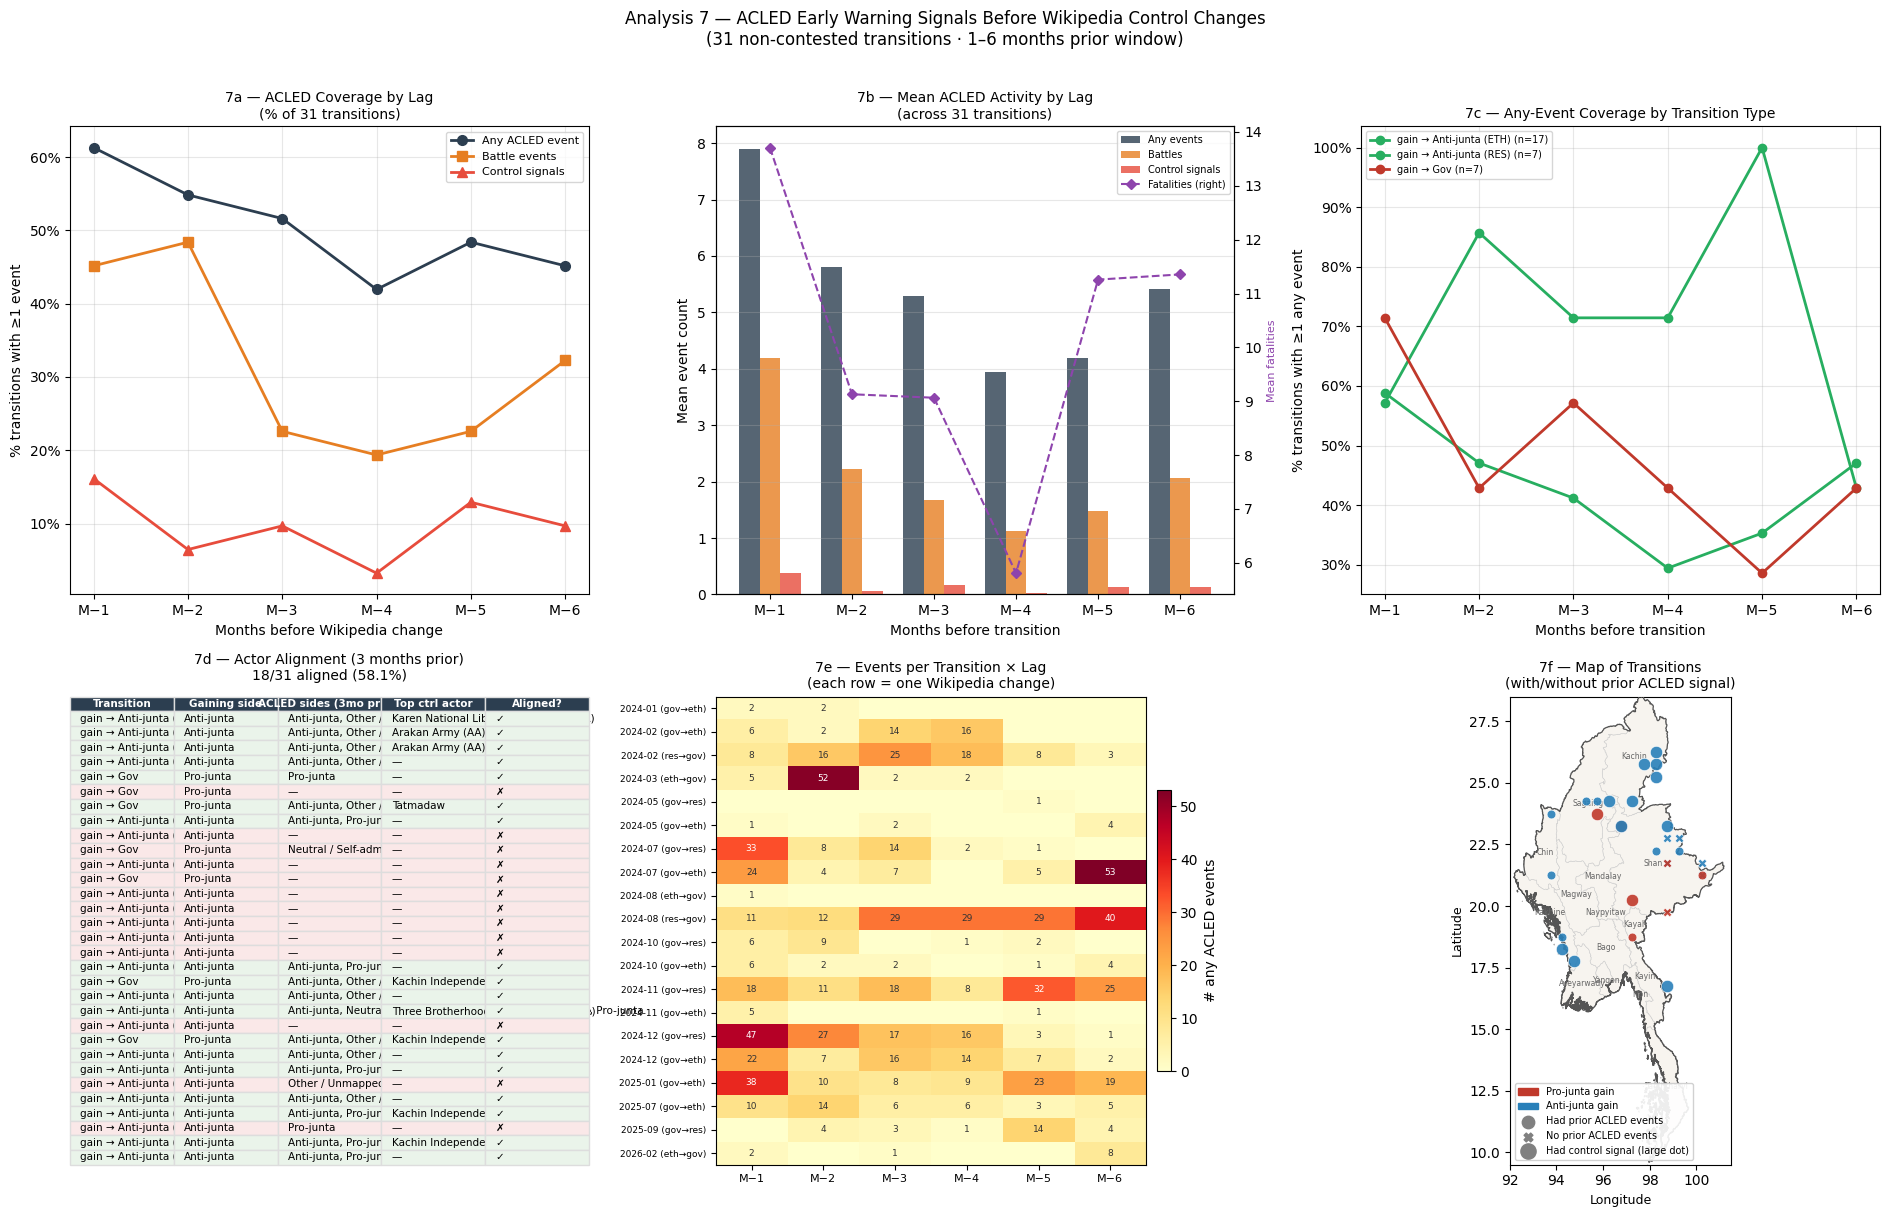

=== Summary ===
M−1: any=61.3%  battle=45.2%  ctrl=16.1%  mean_events=7.9  mean_fatal=13.7
M−2: any=54.8%  battle=48.4%  ctrl=6.5%  mean_events=5.8  mean_fatal=9.1
M−3: any=51.6%  battle=22.6%  ctrl=9.7%  mean_events=5.3  mean_fatal=9.1
M−4: any=41.9%  battle=19.4%  ctrl=3.2%  mean_events=3.9  mean_fatal=5.8
M−5: any=48.4%  battle=22.6%  ctrl=12.9%  mean_events=4.2  mean_fatal=11.3
M−6: any=45.2%  battle=32.3%  ctrl=9.7%  mean_events=5.4  mean_fatal=11.4

Actor aligned (3mo prior): 58.1%


In [14]:
SIDE_PAL = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}
DIR_PAL  = {
    'gain → Gov':             '#c0392b',
    'gain → Anti-junta\n(eth)': '#2980b9',
    'gain → Anti-junta\n(res)': '#27ae60',
}

fig, axes = plt.subplots(2, 3, figsize=(19, 12))

# ── 7a: coverage by lag (any / ctrl / battle) ────────────────────────────────
ax = axes[0, 0]
cov_any    = lag_df.groupby('lag')['has_any'].mean()
cov_ctrl   = lag_df.groupby('lag')['has_ctrl'].mean()
cov_battle = lag_df.groupby('lag')['has_battle'].mean()
ax.plot(LAGS, cov_any    * 100, 'o-', lw=2, ms=7, color='#2C3E50', label='Any ACLED event')
ax.plot(LAGS, cov_battle * 100, 's-', lw=2, ms=7, color='#E67E22', label='Battle events')
ax.plot(LAGS, cov_ctrl   * 100, '^-', lw=2, ms=7, color='#E74C3C', label='Control signals')
ax.set_xlabel('Months before Wikipedia change'); ax.set_ylabel('% transitions with ≥1 event')
ax.set_title('7a — ACLED Coverage by Lag\n(% of 31 transitions)', fontsize=10)
ax.set_xticks(LAGS); ax.set_xticklabels([f'M−{l}' for l in LAGS])
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=8); ax.grid(alpha=.3)

# ── 7b: mean event count by lag ───────────────────────────────────────────────
ax = axes[0, 1]
mean_any    = lag_df.groupby('lag')['n_any'].mean()
mean_battle = lag_df.groupby('lag')['n_battle'].mean()
mean_ctrl   = lag_df.groupby('lag')['n_ctrl'].mean()
mean_fatal  = lag_df.groupby('lag')['fatalities'].mean()
ax.bar(np.array(LAGS) - 0.25, mean_any,    0.25, color='#2C3E50', alpha=.8, label='Any events')
ax.bar(np.array(LAGS),        mean_battle, 0.25, color='#E67E22', alpha=.8, label='Battles')
ax.bar(np.array(LAGS) + 0.25, mean_ctrl,   0.25, color='#E74C3C', alpha=.8, label='Control signals')
ax2b = ax.twinx()
ax2b.plot(LAGS, mean_fatal, 'D--', color='#8E44AD', lw=1.5, ms=5, label='Fatalities (right)')
ax2b.set_ylabel('Mean fatalities', fontsize=8, color='#8E44AD')
ax.set_xlabel('Months before transition'); ax.set_ylabel('Mean event count')
ax.set_title('7b — Mean ACLED Activity by Lag\n(across 31 transitions)', fontsize=10)
ax.set_xticks(LAGS); ax.set_xticklabels([f'M−{l}' for l in LAGS])
lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2b.get_legend_handles_labels()
ax.legend(lines1+lines2, lbs1+lbs2, fontsize=7); ax.grid(axis='y', alpha=.3)

# ── 7c: coverage by direction ─────────────────────────────────────────────────
ax = axes[0, 2]
dirs = trans['direction'].unique()
dir_cov = []
for d in dirs:
    sub = lag_df[lag_df['direction'] == d]
    for l in LAGS:
        sl = sub[sub['lag'] == l]
        dir_cov.append({'direction': d, 'lag': l,
                        'cov_any':  sl['has_any'].mean(),
                        'cov_ctrl': sl['has_ctrl'].mean()})
dir_cov_df = pd.DataFrame(dir_cov)

for d, grp in dir_cov_df.groupby('direction'):
    n = (trans['direction'] == d).sum()
    col = '#c0392b' if 'Gov' in d else ('#2980b9' if 'eth' in d else '#27ae60')
    ax.plot(grp['lag'], grp['cov_any'] * 100, 'o-', lw=2, ms=6, color=col,
            label=f'{d.replace(chr(10)," ")} (n={n})')
ax.set_xlabel('Months before transition'); ax.set_ylabel('% transitions with ≥1 any event')
ax.set_title('7c — Any-Event Coverage by Transition Type', fontsize=10)
ax.set_xticks(LAGS); ax.set_xticklabels([f'M−{l}' for l in LAGS])
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=7); ax.grid(alpha=.3)

# ── 7d: actor alignment table ────────────────────────────────────────────────
ax = axes[1, 0]
ax.axis('off')
aligned_pct = align_df['actor_aligned'].mean()
tbl_data = [
    [row['direction'].replace('\n',' '), row['gaining_side'],
     row['sides_in_prior_acled'], row['top_ctrl_actor'],
     '✓' if row['actor_aligned'] else '✗']
    for _, row in align_df.iterrows()
]
tbl = ax.table(
    cellText=tbl_data,
    colLabels=['Transition','Gaining side','ACLED sides (3mo prior)','Top ctrl actor','Aligned?'],
    cellLoc='left', loc='center', bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if r == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif tbl_data[r-1][-1] == '✓':
        cell.set_facecolor('#EAF4EA')
    else:
        cell.set_facecolor('#FAE8E8')
ax.set_title(f'7d — Actor Alignment (3 months prior)\n'
             f'{align_df["actor_aligned"].sum()}/{len(align_df)} aligned ({aligned_pct:.1%})',
             fontsize=10, pad=12)

# ── 7e: heatmap — each transition × each lag ─────────────────────────────────
ax = axes[1, 1]
# Use composite key (ym + transition) to avoid collapsing duplicate GIDs
lag_df['trans_key'] = (lag_df['ym'] + ' ('
                       + lag_df['prev_status'].str[:3] + '→'
                       + lag_df['new_status'].str[:3] + ')')
pivot_any = lag_df.pivot_table('n_any', 'trans_key', 'lag', aggfunc='sum')
# sort rows to match chronological order of trans
key_order = (lag_df[['ym','trans_key']].drop_duplicates()
             .sort_values('ym')['trans_key'].tolist())
pivot_any = pivot_any.reindex(key_order)

im7 = ax.imshow(pivot_any.values, aspect='auto', cmap='YlOrRd',
                interpolation='none', vmin=0)
ax.set_xticks(range(len(LAGS))); ax.set_xticklabels([f'M−{l}' for l in LAGS], fontsize=8)
ax.set_yticks(range(len(pivot_any))); ax.set_yticklabels(pivot_any.index, fontsize=6.5)
for i in range(len(pivot_any.index)):
    for j in range(len(LAGS)):
        v = int(pivot_any.values[i, j])
        if v > 0:
            c = 'white' if v > pivot_any.values.max() * 0.6 else '#333'
            ax.text(j, i, str(v), ha='center', va='center', fontsize=6.5, color=c)
plt.colorbar(im7, ax=ax, shrink=0.6, pad=0.02, label='# any ACLED events')
ax.set_title('7e — Events per Transition × Lag\n(each row = one Wikipedia change)', fontsize=10)

# ── 7f: map of transitions with ACLED signal flag ────────────────────────────
ax = axes[1, 2]; bg(ax)
# aggregate by (gid, ym) to preserve distinct transitions for cells that appear multiple times
any_prior  = lag_df.groupby(['gid','ym'])['has_any'].any().reset_index()
ctrl_prior = lag_df.groupby(['gid','ym'])['has_ctrl'].any().reset_index()

trans_map = trans.copy()
trans_map = trans_map.merge(
    any_prior.rename(columns={'gid':'priogrid_gid','ym':'year_month','has_any':'had_any_prior'}),
    on=['priogrid_gid','year_month'], how='left')
trans_map = trans_map.merge(
    ctrl_prior.rename(columns={'gid':'priogrid_gid','ym':'year_month','has_ctrl':'had_ctrl_prior'}),
    on=['priogrid_gid','year_month'], how='left')
trans_map['lon'], trans_map['lat'] = zip(
    *trans_map['priogrid_gid'].apply(gid_to_centroid))

# color by gaining side + signal
for _, r in trans_map.iterrows():
    col  = '#c0392b' if r['gaining_side'] == 'Pro-junta' else '#2980b9'
    mark = 'o' if r['had_any_prior'] else 'X'
    sz   = 80 if r['had_ctrl_prior'] else 40
    ax.scatter(r['lon'], r['lat'], c=col, s=sz, marker=mark,
               alpha=0.9, linewidths=0.5, edgecolors='white', zorder=6)

legend_els = [
    mpatches.Patch(color='#c0392b', label='Pro-junta gain'),
    mpatches.Patch(color='#2980b9', label='Anti-junta gain'),
    plt.scatter([], [], c='grey', s=80, marker='o', label='Had prior ACLED events'),
    plt.scatter([], [], c='grey', s=40, marker='X', label='No prior ACLED events'),
    plt.scatter([], [], c='grey', s=120, marker='o', label='Had control signal (large dot)'),
]
ax.legend(handles=legend_els, fontsize=7, loc='lower left', framealpha=0.9)
ax.set_title('7f — Map of Transitions\n(with/without prior ACLED signal)', fontsize=10)

plt.suptitle('Analysis 7 — ACLED Early Warning Signals Before Wikipedia Control Changes\n'
             f'({len(trans)} non-contested transitions · 1–6 months prior window)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'analysis7_early_warning.png', dpi=150, bbox_inches='tight')
plt.show()

# summary printout
print('=== Summary ===')
for lag in LAGS:
    sub = lag_df[lag_df['lag'] == lag]
    print(f'M−{lag}: any={sub["has_any"].mean():.1%}  battle={sub["has_battle"].mean():.1%}'
          f'  ctrl={sub["has_ctrl"].mean():.1%}  mean_events={sub["n_any"].mean():.1f}'
          f'  mean_fatal={sub["fatalities"].mean():.1f}')
print(f'\nActor aligned (3mo prior): {align_df["actor_aligned"].mean():.1%}')

---
## Analysis 8 — Do Prior Control Signal Events Match the Direction of Wikipedia Transitions?

For each non-contested transition, we flag:
- **`had_ctrl_3mo`**: was there at least one ACLED control-signal event in the same cell in M−1/M−2/M−3?
- **`ctrl_match`**: among those control signal events, did any have `side == gaining_side` in Wikipedia?

A `ctrl_match=True` means ACLED not only showed territorial activity in advance, but the *right side* was making the move.

In [15]:
# sub_event_type → expected gaining side (used as secondary check)
SUBTYPE_SIDE = {
    'Government regains territory':        'Pro-junta',
    'Non-state actor overtakes territory': 'Anti-junta',
    'Non-violent transfer of territory':   None,   # ambiguous
    'Headquarters or base established':    None,   # ambiguous
}

records = []
for _, row in trans.iterrows():
    gid     = row['priogrid_gid']
    ym      = row['year_month']
    gaining = row['gaining_side']
    prior_months = [str(pd.Period(ym, 'M') - k) for k in range(1, 4)]

    prior_all  = acled_full[(acled_full['priogrid_gid'] == gid) &
                             (acled_full['year_month'].isin(prior_months))]
    prior_ctrl = prior_all[prior_all['is_control_signal']]

    had_ctrl    = len(prior_ctrl) > 0
    n_ctrl      = len(prior_ctrl)

    # side alignment: gaining side appears in a control signal event
    side_match  = bool((prior_ctrl['side'] == gaining).any()) if had_ctrl else False

    # subtype alignment: a sub_event_type unambiguously points to gaining side
    subtype_match = False
    matched_subtype = None
    if had_ctrl:
        for _, ev in prior_ctrl.iterrows():
            expected = SUBTYPE_SIDE.get(ev['sub_event_type'])
            if expected == gaining:
                subtype_match  = True
                matched_subtype = ev['sub_event_type']
                break

    # overall: either side OR subtype agrees
    any_match = side_match or subtype_match

    top_ctrl_actor = (prior_ctrl['actor_group'].value_counts().index[0]
                      if had_ctrl else '—')
    ctrl_subtypes  = prior_ctrl['sub_event_type'].value_counts().to_dict() if had_ctrl else {}

    records.append({
        'gid':            gid,
        'ym':             ym,
        'prev_status':    row['prev_status'],
        'new_status':     row['control_status'],
        'direction':      row['direction'],
        'gaining_side':   gaining,
        'n_any_3mo':      len(prior_all),
        'had_ctrl_3mo':   had_ctrl,
        'n_ctrl_3mo':     n_ctrl,
        'side_match':     side_match,
        'subtype_match':  subtype_match,
        'any_match':      any_match,
        'top_ctrl_actor': top_ctrl_actor,
        'ctrl_subtypes':  str(ctrl_subtypes) if ctrl_subtypes else '—',
    })

match_df = pd.DataFrame(records)

n  = len(match_df)
n_had  = match_df['had_ctrl_3mo'].sum()
n_side = match_df['side_match'].sum()
n_sub  = match_df['subtype_match'].sum()
n_any  = match_df['any_match'].sum()

print(f'Total non-contested transitions: {n}')
print()
print(f'Had ≥1 control signal in M−1/−2/−3:   {n_had:2d} / {n}  ({n_had/n:.1%})')
print(f'  of which side matched gaining side:  {n_side:2d} / {n_had}  ({n_side/n_had:.1%} of those with ctrl signal)')
print(f'  of which subtype matched:            {n_sub:2d} / {n_had}  ({n_sub/n_had:.1%})')
print(f'  any match (side OR subtype):         {n_any:2d} / {n_had}  ({n_any/n_had:.1%})')
print()
print(f'As fraction of ALL 31 transitions:')
print(f'  had ctrl + matched:                  {n_any:2d} / {n}  ({n_any/n:.1%})')
print()
print(match_df[['ym','prev_status','new_status','gaining_side',
               'had_ctrl_3mo','n_ctrl_3mo','side_match','subtype_match',
               'top_ctrl_actor']].to_string(index=False))

Total non-contested transitions: 31

Had ≥1 control signal in M−1/−2/−3:    9 / 31  (29.0%)
  of which side matched gaining side:   7 / 9  (77.8% of those with ctrl signal)
  of which subtype matched:             4 / 9  (44.4%)
  any match (side OR subtype):          7 / 9  (77.8%)

As fraction of ALL 31 transitions:
  had ctrl + matched:                   7 / 31  (22.6%)

     ym        prev_status         new_status gaining_side  had_ctrl_3mo  n_ctrl_3mo  side_match  subtype_match                          top_ctrl_actor
2025-07         government ethnic_armed_group   Anti-junta          True           1        True          False   Karen National Liberation Army (KNLA)
2024-12         government         resistance   Anti-junta          True           3        True          False                        Arakan Army (AA)
2024-07         government         resistance   Anti-junta          True           3        True           True                        Arakan Army (AA)
2024-11         

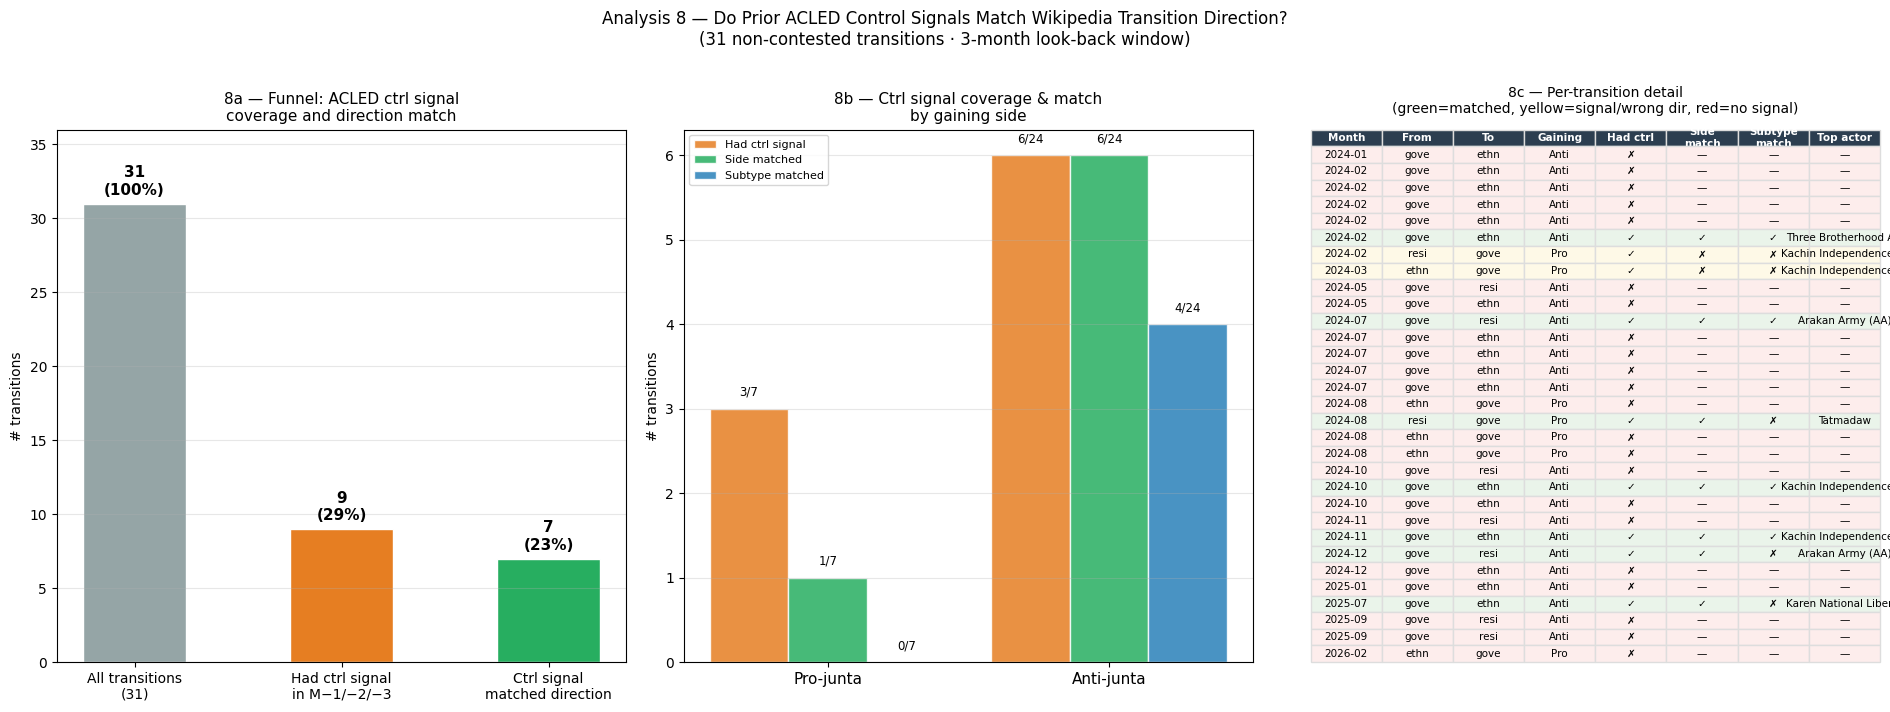

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))

# ── left: funnel — all → had ctrl → matched ──────────────────────────────────
ax = axes[0]
stages  = ['All transitions\n(31)', 'Had ctrl signal\nin M−1/−2/−3', 'Ctrl signal\nmatched direction']
counts  = [n, n_had, n_any]
colors  = ['#95A5A6', '#E67E22', '#27AE60']
bars = ax.bar(stages, counts, color=colors, edgecolor='white', width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{cnt}\n({cnt/n:.0%})', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, n + 5)
ax.set_ylabel('# transitions')
ax.set_title('8a — Funnel: ACLED ctrl signal\ncoverage and direction match', fontsize=11)
ax.grid(axis='y', alpha=.3)

# ── middle: breakdown by gaining side ────────────────────────────────────────
ax = axes[1]
sides = ['Pro-junta', 'Anti-junta']
x = np.arange(len(sides)); w = 0.28
for i, col_key, label, color in [
    (0, 'had_ctrl_3mo', 'Had ctrl signal',     '#E67E22'),
    (1, 'side_match',   'Side matched',         '#27AE60'),
    (2, 'subtype_match','Subtype matched',      '#2980B9'),
]:
    vals = [match_df[match_df['gaining_side'] == s][col_key].sum() for s in sides]
    tots = [match_df['gaining_side'].eq(s).sum() for s in sides]
    ax.bar(x + (i-1)*w, vals, w, label=label, color=color, edgecolor='white', alpha=0.85)
    for xi, (v, t) in enumerate(zip(vals, tots)):
        ax.text(xi + (i-1)*w, v + 0.15, f'{v}/{t}', ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(sides, fontsize=11)
ax.set_ylabel('# transitions')
ax.set_title('8b — Ctrl signal coverage & match\nby gaining side', fontsize=11)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)

# ── right: per-transition strip — colour by match outcome ───────────────────
ax = axes[2]
ax.axis('off')

col_labels = ['Month', 'From', 'To', 'Gaining', 'Had ctrl', 'Side\nmatch', 'Subtype\nmatch', 'Top actor']
table_data = []
for _, r in match_df.sort_values('ym').iterrows():
    table_data.append([
        r['ym'],
        r['prev_status'][:4],
        r['new_status'][:4],
        r['gaining_side'].replace('-junta',''),
        '✓' if r['had_ctrl_3mo'] else '✗',
        '✓' if r['side_match']   else ('—' if not r['had_ctrl_3mo'] else '✗'),
        '✓' if r['subtype_match']else ('—' if not r['had_ctrl_3mo'] else '✗'),
        r['top_ctrl_actor'][:22] if r['top_ctrl_actor'] != '—' else '—',
    ])

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        row_data = table_data[r - 1]
        had  = row_data[4] == '✓'
        ok   = row_data[5] == '✓' or row_data[6] == '✓'
        if had and ok:
            cell.set_facecolor('#EAF4EA')   # green: had signal + matched
        elif had and not ok:
            cell.set_facecolor('#FEF9E7')   # yellow: had signal but wrong direction
        else:
            cell.set_facecolor('#FDEDEC')   # red: no ctrl signal at all

ax.set_title('8c — Per-transition detail\n(green=matched, yellow=signal/wrong dir, red=no signal)',
             fontsize=10, pad=12)

plt.suptitle('Analysis 8 — Do Prior ACLED Control Signals Match Wikipedia Transition Direction?\n'
             f'({n} non-contested transitions · 3-month look-back window)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'analysis8_ctrl_signal_match.png', dpi=150, bbox_inches='tight')
plt.show()

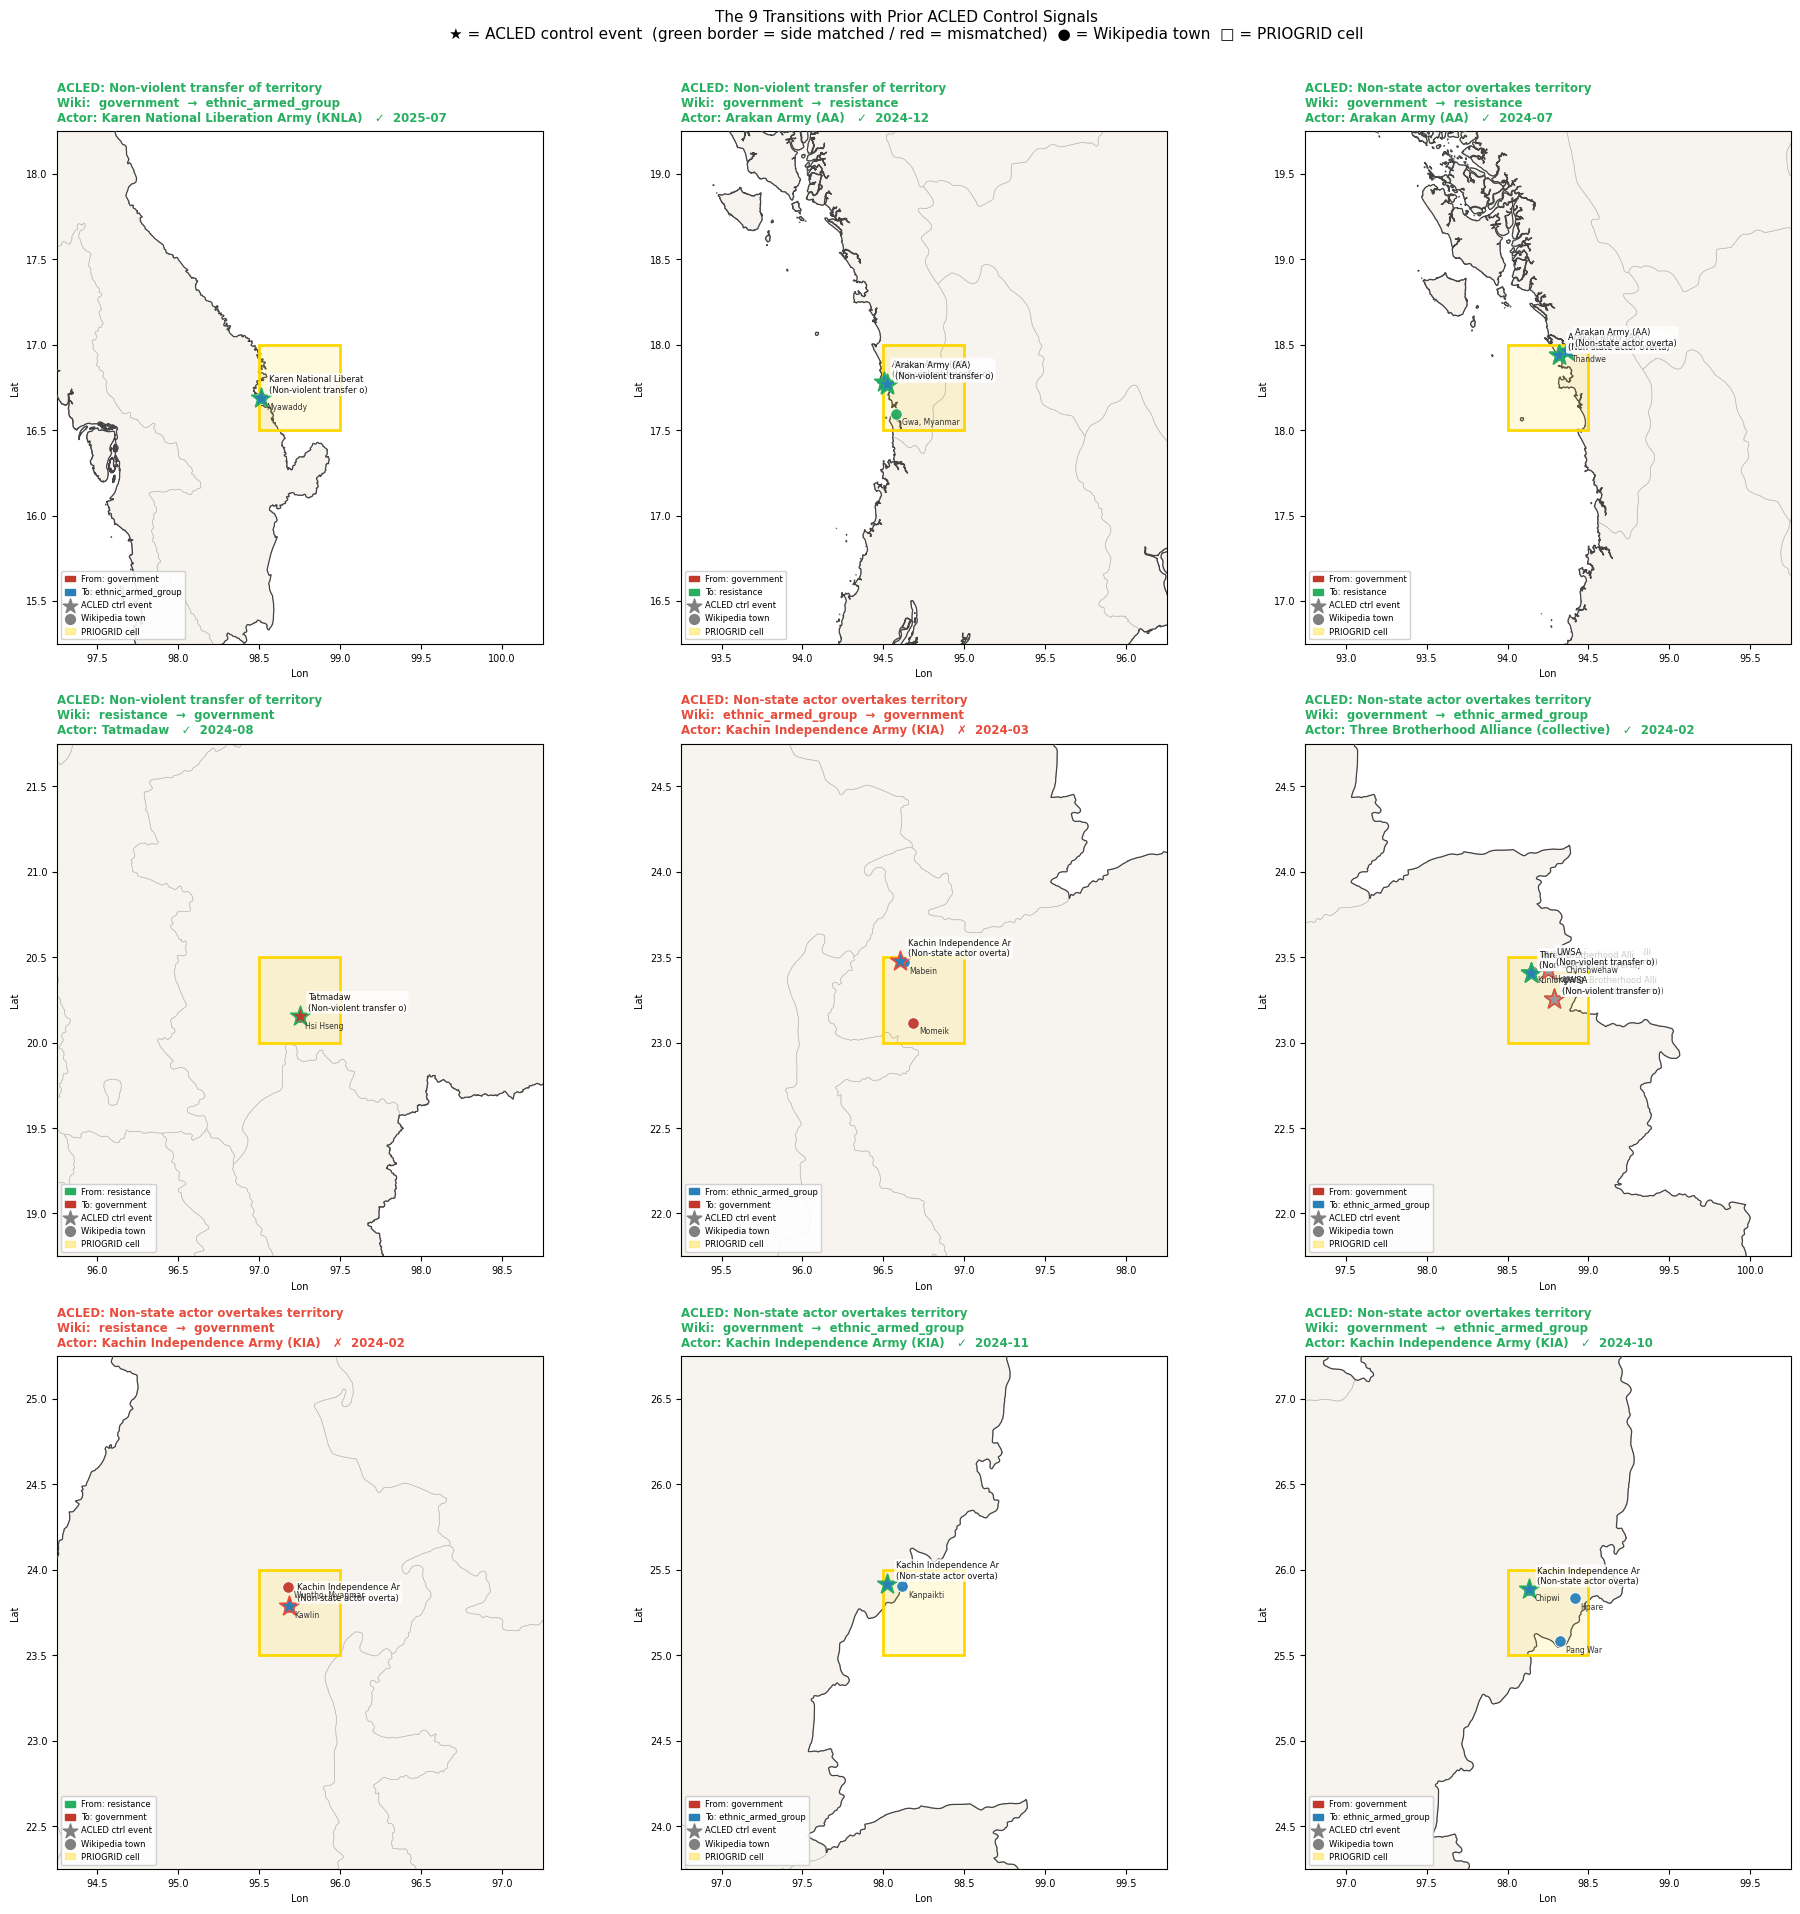

In [17]:
from matplotlib.patches import Rectangle

SIDE_COL   = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}
MATCH_EDGE = {True: '#27AE60', False: '#E74C3C'}
STATUS_COL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}

nine = match_df[match_df['had_ctrl_3mo']].reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(19, 19))
axes = axes.flatten()

for ax_i, (_, row) in enumerate(nine.iterrows()):
    ax      = axes[ax_i]
    gid     = row['gid']
    ym      = row['ym']
    gaining = row['gaining_side']
    matched = row['side_match'] or row['subtype_match']

    # cell bounding box
    cell_r  = (gid - 1) // 720;  cell_c = (gid - 1) % 720
    lon_min = cell_c * 0.5 - 180; lat_min = cell_r * 0.5 - 90
    clon = lon_min + 0.25;         clat = lat_min + 0.25
    buf  = 1.5
    xl = (clon - buf, clon + buf); yl = (clat - buf, clat + buf)

    # base map
    gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#bbbbbb', linewidth=0.5, zorder=1)
    gadm0.boundary.plot(ax=ax, color='#444', linewidth=0.9, zorder=3)
    ax.add_patch(Rectangle((lon_min, lat_min), 0.5, 0.5,
                            linewidth=2, edgecolor='#FFD700',
                            facecolor='#FFD70022', zorder=4))

    # ACLED control signal events in prior 3 months
    prior_months = [str(pd.Period(ym, 'M') - k) for k in range(1, 4)]
    prior_ctrl = acled_full[
        (acled_full['priogrid_gid'] == gid) &
        (acled_full['year_month'].isin(prior_months)) &
        (acled_full['is_control_signal'])
    ]

    # top sub_event_type for title
    top_subtype = prior_ctrl['sub_event_type'].value_counts().index[0] if len(prior_ctrl) else '—'

    for _, ev in prior_ctrl.iterrows():
        edge_col = MATCH_EDGE[ev['side'] == gaining]
        ax.scatter(ev['longitude'], ev['latitude'],
                   c=SIDE_COL.get(ev['side'], '#999'),
                   s=220, marker='*', linewidths=1.2,
                   edgecolors=edge_col, zorder=7)
        ax.annotate(f"{ev['actor_group'][:22]}\n({ev['sub_event_type'][:22]})",
                    (ev['longitude'], ev['latitude']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=6, color='#111', zorder=8,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.78, ec='none'))

    # Wikipedia towns at transition month
    cell_wiki = wiki[
        (wiki['priogrid_gid'] == gid) &
        (wiki['year_month'] == ym)
    ]
    for _, tw in cell_wiki.iterrows():
        ax.scatter(tw['lon'], tw['lat'],
                   c=STATUS_COL.get(tw['control_status'], '#999'),
                   s=70, marker='o', linewidths=0.7,
                   edgecolors='white', zorder=6, alpha=0.95)
        ax.annotate(tw['location_name'][:18],
                    (tw['lon'], tw['lat']),
                    textcoords='offset points', xytext=(4, -8),
                    fontsize=5.5, color='#333', zorder=8)

    ax.set_xlim(*xl); ax.set_ylim(*yl)
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Lon', fontsize=7); ax.set_ylabel('Lat', fontsize=7)

    # ── title: ACLED from→to  |  Wiki who→who  |  Actor ────────────────────
    match_sym = '✓' if matched else '✗'
    match_col = '#27AE60' if matched else '#E74C3C'

    title_lines = [
        f"ACLED: {top_subtype}",
        f"Wiki:  {row['prev_status']}  →  {row['new_status']}",
        f"Actor: {row['top_ctrl_actor']}   {match_sym}  {ym}",
    ]
    ax.set_title('\n'.join(title_lines), fontsize=8.5, pad=7,
                 color=match_col, fontweight='bold', loc='left')

    leg_els = [
        mpatches.Patch(color=STATUS_COL.get(row['prev_status'], '#999'),
                       label=f"From: {row['prev_status']}"),
        mpatches.Patch(color=STATUS_COL.get(row['new_status'], '#999'),
                       label=f"To: {row['new_status']}"),
        plt.scatter([], [], c='grey', s=120, marker='*', label='ACLED ctrl event'),
        plt.scatter([], [], c='grey', s=50,  marker='o', label='Wikipedia town'),
        mpatches.Patch(facecolor='#FFD700', alpha=0.35, edgecolor='#FFD700',
                       label='PRIOGRID cell'),
    ]
    ax.legend(handles=leg_els, fontsize=6, loc='lower left',
              framealpha=0.88, handlelength=1.2)

plt.suptitle(
    'The 9 Transitions with Prior ACLED Control Signals\n'
    '★ = ACLED control event  (green border = side matched / red = mismatched)  '
    '● = Wikipedia town  □ = PRIOGRID cell',
    fontsize=11, y=1.005)
plt.tight_layout()
plt.savefig(FIG / 'analysis8_ctrl_signal_maps.png', dpi=150, bbox_inches='tight')
plt.show()

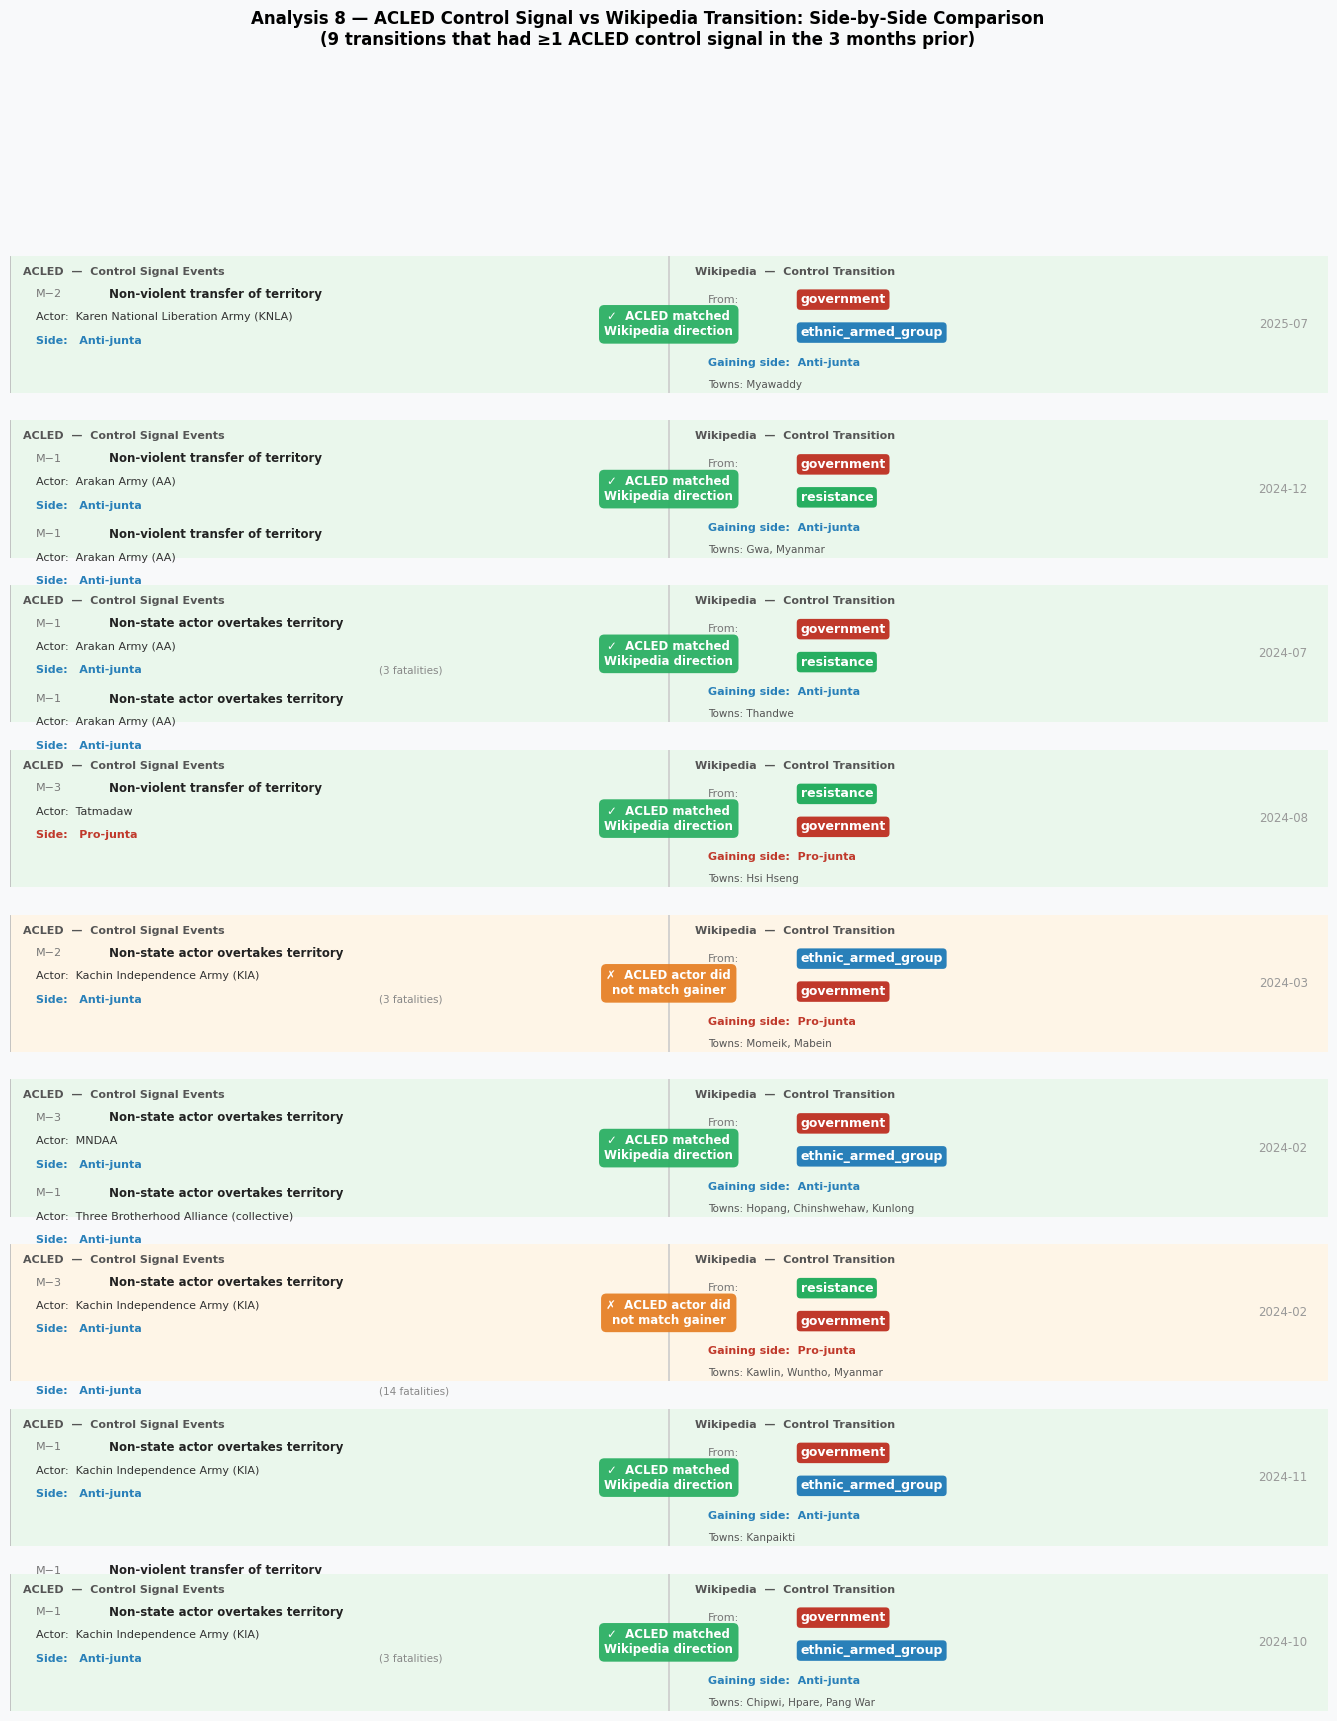

In [18]:
# ── collect full ACLED event details for the 9 transitions ──────────────────
nine = match_df[match_df['had_ctrl_3mo']].reset_index(drop=True)

case_details = []
for _, row in nine.iterrows():
    gid, ym, gaining = row['gid'], row['ym'], row['gaining_side']
    prior_months = [str(pd.Period(ym, 'M') - k) for k in range(1, 4)]

    prior_ctrl = acled_full[
        (acled_full['priogrid_gid'] == gid) &
        (acled_full['year_month'].isin(prior_months)) &
        (acled_full['is_control_signal'])
    ][['year_month','actor_group','sub_event_type','side','fatalities']].copy()

    wiki_towns = wiki[
        (wiki['priogrid_gid'] == gid) &
        (wiki['year_month'] == ym)
    ]['location_name'].tolist()

    case_details.append({
        'row':        row,
        'prior_ctrl': prior_ctrl,
        'wiki_towns': wiki_towns,
    })

# ── figure: one row per transition ───────────────────────────────────────────
STATUS_COL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}
SIDE_COL = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}

n_cases = len(case_details)
fig, axes = plt.subplots(n_cases, 1, figsize=(17, n_cases * 2.1))
fig.patch.set_facecolor('#F8F9FA')

for ax_i, case in enumerate(case_details):
    ax  = axes[ax_i]
    row = case['row']
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

    matched = row['side_match'] or row['subtype_match']
    bg_col  = '#EAF7EC' if matched else '#FEF5E7'
    ax.set_facecolor(bg_col)
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                color=bg_col, zorder=0))

    # ── DIVIDER line ─────────────────────────────────────────────────────────
    ax.axvline(0.5, color='#CCCCCC', lw=1.2, zorder=1)
    ax.axvline(0.0, color='#BBBBBB', lw=0.6)

    # ── MATCH badge ──────────────────────────────────────────────────────────
    badge_col = '#27AE60' if matched else '#E67E22'
    badge_txt = '✓  ACLED matched\nWikipedia direction' if matched else '✗  ACLED actor did\nnot match gainer'
    ax.text(0.5, 0.5, badge_txt, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.45', fc=badge_col, ec='none', alpha=0.92),
            transform=ax.transAxes, zorder=5)

    # ════════════════  LEFT: ACLED  ══════════════════════════════════════════
    ax.text(0.01, 0.92, 'ACLED  —  Control Signal Events', fontsize=8,
            fontweight='bold', color='#555', va='top', transform=ax.transAxes)

    ctrl_df = case['prior_ctrl']
    y_start = 0.72
    for _, ev in ctrl_df.iterrows():
        lag = int((pd.Period(row['ym'],'M') - pd.Period(ev['year_month'],'M')).n)
        side_col = SIDE_COL.get(ev['side'], '#888')
        # event type pill
        ax.text(0.02, y_start,
                f"M−{lag}",
                fontsize=8, color='#777', va='center', transform=ax.transAxes)
        ax.text(0.075, y_start,
                ev['sub_event_type'],
                fontsize=8.5, color='#222', fontweight='bold',
                va='center', transform=ax.transAxes)
        ax.text(0.02, y_start - 0.17,
                f"Actor:  {ev['actor_group']}",
                fontsize=8, color='#333', va='center', transform=ax.transAxes)
        ax.text(0.02, y_start - 0.34,
                f"Side:   {ev['side']}",
                fontsize=8, color=side_col, fontweight='bold',
                va='center', transform=ax.transAxes)
        if ev['fatalities'] > 0:
            ax.text(0.28, y_start - 0.34,
                    f"({int(ev['fatalities'])} fatalities)",
                    fontsize=7.5, color='#888', va='center', transform=ax.transAxes)
        y_start -= 0.55

    # ════════════════  RIGHT: WIKIPEDIA  ════════════════════════════════════
    ax.text(0.52, 0.92, 'Wikipedia  —  Control Transition', fontsize=8,
            fontweight='bold', color='#555', va='top', transform=ax.transAxes)

    prev_col = STATUS_COL.get(row['prev_status'], '#888')
    new_col  = STATUS_COL.get(row['new_status'],  '#888')
    gaining_col = SIDE_COL.get(row['gaining_side'], '#888')

    # from → to with coloured boxes
    ax.text(0.53, 0.68, 'From:', fontsize=8, color='#777', va='center', transform=ax.transAxes)
    ax.text(0.60, 0.68, row['prev_status'], fontsize=9, fontweight='bold',
            color='white', va='center', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', fc=prev_col, ec='none'))
    ax.text(0.53, 0.44, 'To:', fontsize=8, color='#777', va='center', transform=ax.transAxes)
    ax.text(0.60, 0.44, row['new_status'], fontsize=9, fontweight='bold',
            color='white', va='center', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', fc=new_col, ec='none'))

    # gaining side
    ax.text(0.53, 0.22,
            f"Gaining side:  {row['gaining_side']}",
            fontsize=8, color=gaining_col, fontweight='bold',
            va='center', transform=ax.transAxes)

    # towns
    towns_str = ', '.join(case['wiki_towns'][:5])
    if len(case['wiki_towns']) > 5:
        towns_str += f' (+{len(case["wiki_towns"])-5} more)'
    ax.text(0.53, 0.06,
            f"Towns: {towns_str}",
            fontsize=7.5, color='#555', va='center', transform=ax.transAxes)

    # transition month label on the right edge
    ax.text(0.985, 0.5, row['ym'], fontsize=8.5, color='#999',
            ha='right', va='center', transform=ax.transAxes, rotation=0)

plt.suptitle(
    'Analysis 8 — ACLED Control Signal vs Wikipedia Transition: Side-by-Side Comparison\n'
    f'(9 transitions that had ≥1 ACLED control signal in the 3 months prior)',
    fontsize=12, y=1.01, fontweight='bold')
plt.tight_layout(h_pad=0.3)
plt.savefig(FIG / 'analysis8_comparison_cards.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 9 — ACLED → Wikipedia: Does Wikipedia Confirm ACLED Control Signals?

Reverse direction of Analysis 7/8. Instead of starting from Wikipedia transitions and looking back at ACLED, we now start from every ACLED territorial control event and ask: **did Wikipedia update its label to match in the following 1–3 months?**

**Scope:** 390 ACLED control-signal events in cells that have Wikipedia data, within the Wikipedia coverage window (Nov 2023 – Mar 2026).

**Match logic:**
- `Anti-junta` ACLED side → expect Wikipedia to show `resistance` or `ethnic_armed_group`
- `Pro-junta` ACLED side → expect Wikipedia to show `government`
- Confirmed at M+k = Wikipedia label is in the expected set at M+k AND was NOT at M (i.e., a real change occurred)

In [19]:
# ── scope: ACLED ctrl events in wiki cells, within wiki period ────────────────
ctrl_scope = acled_full[
    acled_full['is_control_signal'] &
    acled_full['priogrid_gid'].isin(set(wiki['priogrid_gid'])) &
    (acled_full['year_month'] >= '2023-11') &
    acled_full['side'].isin(['Pro-junta', 'Anti-junta'])
].copy().reset_index(drop=True)

SIDE_TO_WIKI = {
    'Anti-junta': {'resistance', 'ethnic_armed_group'},
    'Pro-junta':  {'government'},
}
SIDE_OPPOSING = {
    'Anti-junta': {'government'},
    'Pro-junta':  {'resistance', 'ethnic_armed_group'},
}

records = []
for _, ev in ctrl_scope.iterrows():
    gid  = ev['priogrid_gid']
    ym   = ev['year_month']
    side = ev['side']
    expected = SIDE_TO_WIKI[side]
    opposing = SIDE_OPPOSING[side]

    wiki_M  = cell_lkup.get((gid, ym))
    wiki_M1 = cell_lkup.get((gid, str(pd.Period(ym,'M') + 1)))
    wiki_M2 = cell_lkup.get((gid, str(pd.Period(ym,'M') + 2)))
    wiki_M3 = cell_lkup.get((gid, str(pd.Period(ym,'M') + 3)))

    conf_M  = wiki_M  in expected if wiki_M  else False
    conf_M1 = wiki_M1 in expected if wiki_M1 else False
    conf_M2 = wiki_M2 in expected if wiki_M2 else False
    conf_M3 = wiki_M3 in expected if wiki_M3 else False

    any_conf = conf_M or conf_M1 or conf_M2 or conf_M3

    # first lag at which confirmation occurs
    first_conf_lag = (0 if conf_M else
                      1 if conf_M1 else
                      2 if conf_M2 else
                      3 if conf_M3 else None)

    # ── categorise "never confirmed" cases ────────────────────────────────────
    all_wiki = [w for w in [wiki_M, wiki_M1, wiki_M2, wiki_M3] if w is not None]

    if any_conf:
        never_conf_reason = None
    elif not all_wiki:
        never_conf_reason = 'No Wiki coverage (M to M+3)'
    elif any(w in opposing for w in all_wiki):
        never_conf_reason = 'Wiki shows opposing side in control'
    elif any(w == 'contested' for w in all_wiki):
        never_conf_reason = 'Wiki shows contested'
    else:
        never_conf_reason = 'Wiki has data but no clear transition'

    records.append({
        'gid':              gid,
        'ym':               ym,
        'side':             side,
        'sub_event_type':   ev['sub_event_type'],
        'actor_group':      ev['actor_group'],
        'fatalities':       ev['fatalities'],
        'wiki_at_M':        wiki_M,
        'wiki_at_M1':       wiki_M1,
        'wiki_at_M2':       wiki_M2,
        'wiki_at_M3':       wiki_M3,
        'conf_M':           conf_M,
        'conf_M1':          conf_M1,
        'conf_M2':          conf_M2,
        'conf_M3':          conf_M3,
        'any_conf':         any_conf,
        'first_conf_lag':   first_conf_lag,
        'never_conf_reason':never_conf_reason,
    })

fwd_df = pd.DataFrame(records)

n        = len(fwd_df)
n_conf   = fwd_df['any_conf'].sum()
n_noconf = n - n_conf

# never-confirmed breakdown
nc = fwd_df[~fwd_df['any_conf']]['never_conf_reason'].value_counts()

print(f'ACLED ctrl events in scope:    {n}')
print(f'Confirmed (M or M+1/2/3):      {n_conf}  ({n_conf/n:.1%})')
print(f'  at M:                         {fwd_df["conf_M"].sum()}')
print(f'  first confirmed at M+1:       {((fwd_df["first_conf_lag"]==1)).sum()}')
print(f'  first confirmed at M+2:       {((fwd_df["first_conf_lag"]==2)).sum()}')
print(f'  first confirmed at M+3:       {((fwd_df["first_conf_lag"]==3)).sum()}')
print(f'Never confirmed:               {n_noconf}  ({n_noconf/n:.1%})')
print()
print('Why never confirmed:')
print(nc.to_string())
print()
print('Confirmed rate by side:')
print(fwd_df.groupby('side')['any_conf']
      .agg(['sum','count', lambda x: x.mean()])
      .rename(columns={'<lambda_0>':'rate'}).round(3).to_string())
print()
print('Confirmed rate by sub_event_type:')
print(fwd_df.groupby('sub_event_type')['any_conf']
      .agg(['sum','count', lambda x: x.mean()])
      .rename(columns={'<lambda_0>':'rate'}).round(3).to_string())

ACLED ctrl events in scope:    380
Confirmed (M or M+1/2/3):      171  (45.0%)
  at M:                         112
  first confirmed at M+1:       35
  first confirmed at M+2:       16
  first confirmed at M+3:       8
Never confirmed:               209  (55.0%)

Why never confirmed:
never_conf_reason
Wiki shows opposing side in control    120
Wiki shows contested                    78
No Wiki coverage (M to M+3)             11

Confirmed rate by side:
            sum  count   rate
side                         
Anti-junta  143    322  0.444
Pro-junta    28     58  0.483

Confirmed rate by sub_event_type:
                                     sum  count   rate
sub_event_type                                        
Government regains territory          15     37  0.405
Headquarters or base established       1      1  1.000
Non-state actor overtakes territory  128    281  0.456
Non-violent transfer of territory     27     61  0.443


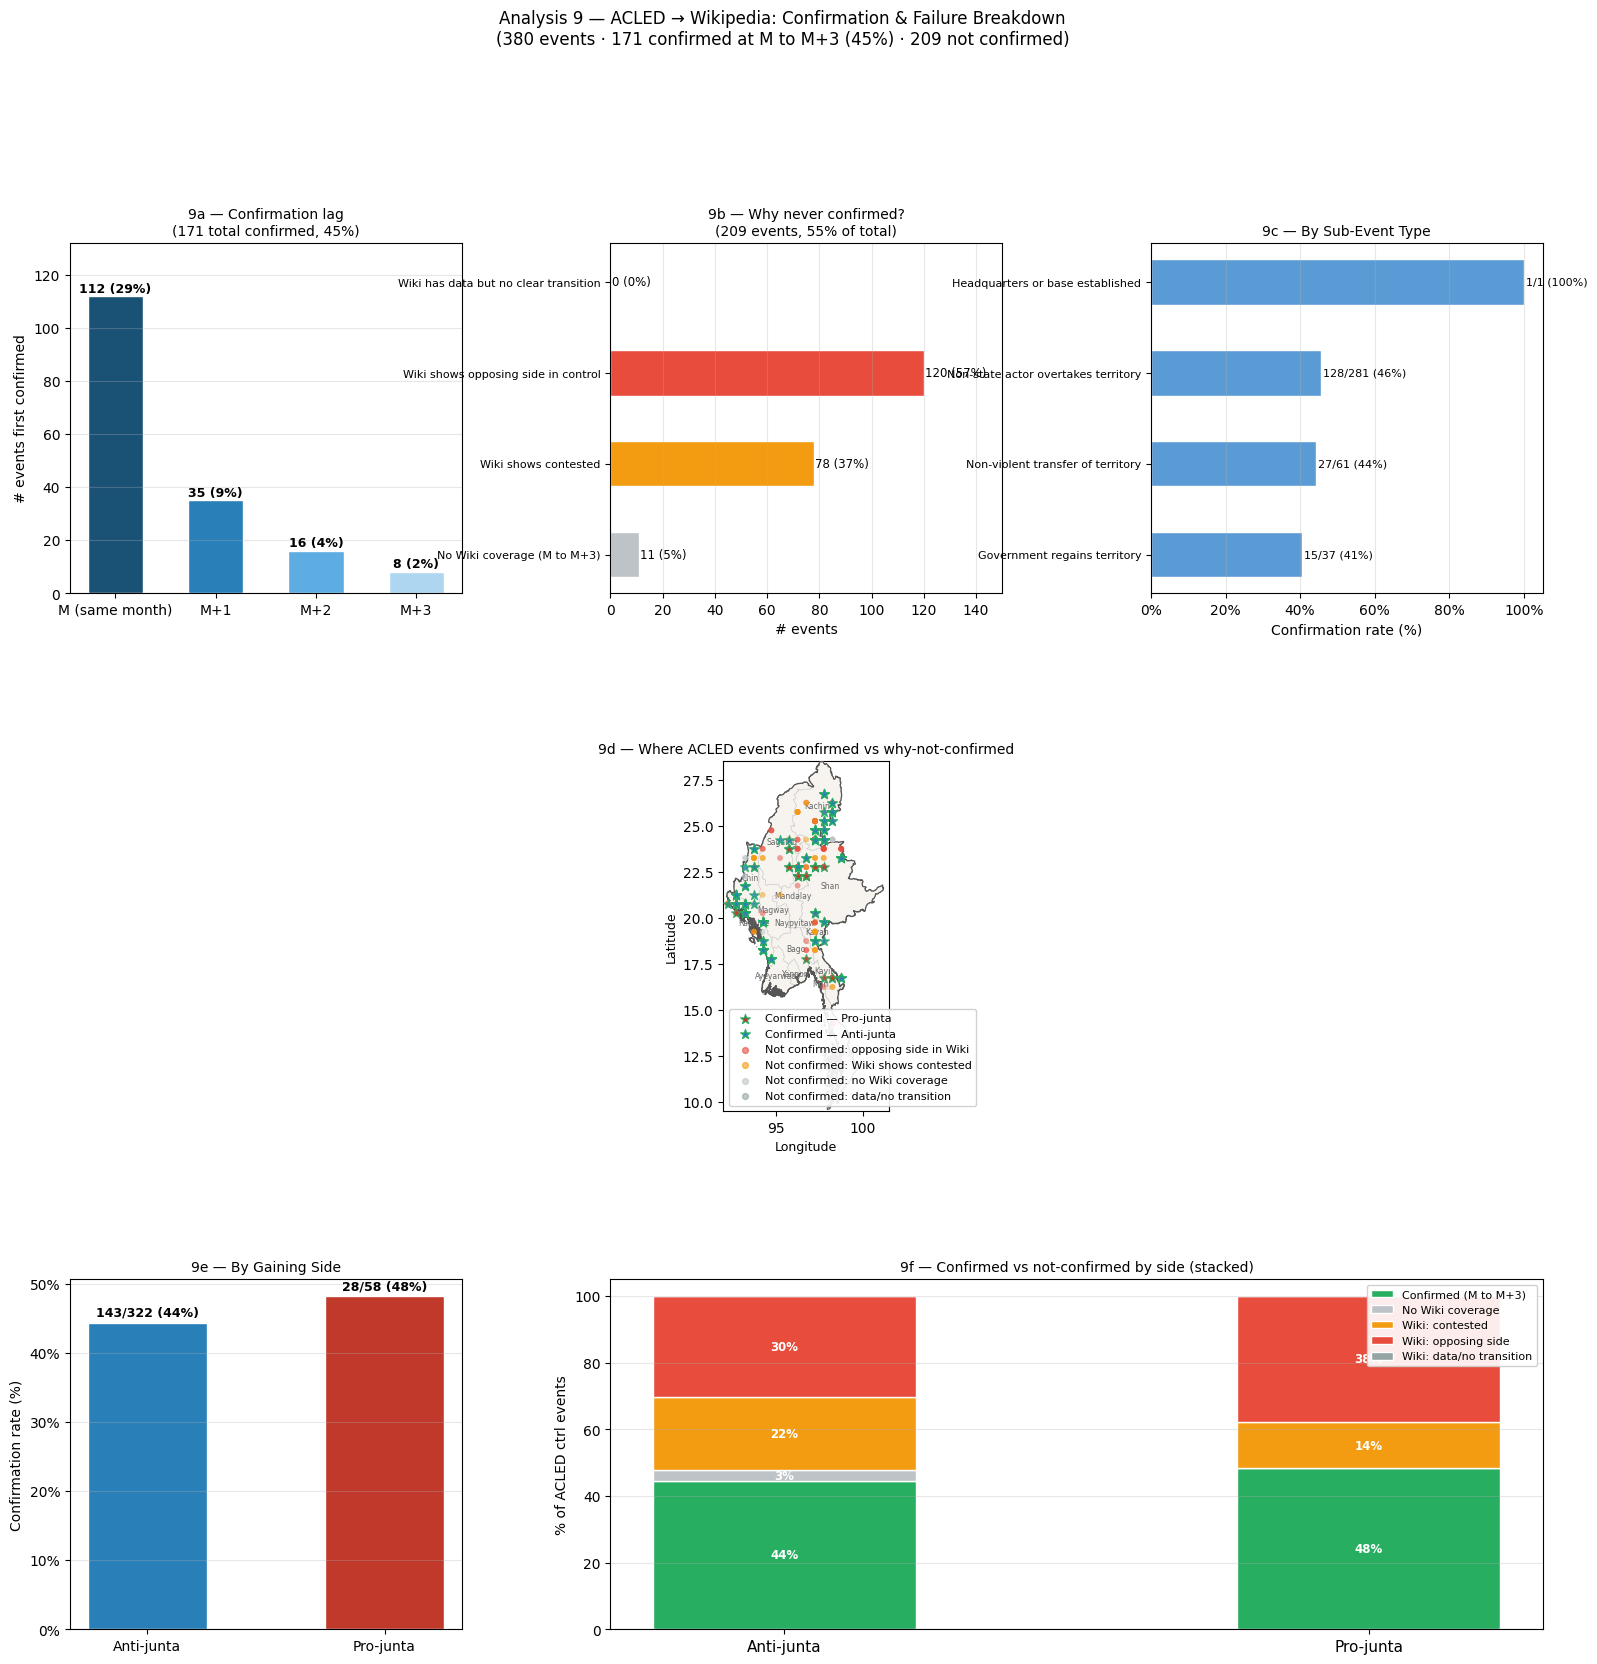

In [20]:
import matplotlib.gridspec as gridspec

STATUS_COL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}
SIDE_COL = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}

fig = plt.figure(figsize=(19, 18))
gs  = fig.add_gridspec(3, 3, hspace=0.48, wspace=0.38)

# 9a: confirmed by first lag
ax = fig.add_subplot(gs[0, 0])
lag_labels = ['M (same month)', 'M+1', 'M+2', 'M+3']
lag_counts = [fwd_df['conf_M'].sum(),
              (fwd_df['first_conf_lag'] == 1).sum(),
              (fwd_df['first_conf_lag'] == 2).sum(),
              (fwd_df['first_conf_lag'] == 3).sum()]
colors_lag = ['#1A5276','#2980B9','#5DADE2','#AED6F1']
bars = ax.bar(lag_labels, lag_counts, color=colors_lag, edgecolor='white', width=0.55)
for bar, cnt in zip(bars, lag_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt} ({cnt/n:.0%})', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('# events first confirmed'); ax.set_ylim(0, max(lag_counts)+20)
ax.set_title(f'9a \u2014 Confirmation lag\n({n_conf} total confirmed, {n_conf/n:.0%})', fontsize=10)
ax.grid(axis='y', alpha=.3)

# 9b: never confirmed breakdown
ax = fig.add_subplot(gs[0, 1])
nc_order = [
    'No Wiki coverage (M to M+3)',
    'Wiki shows contested',
    'Wiki shows opposing side in control',
    'Wiki has data but no clear transition',
]
nc_counts = [fwd_df[~fwd_df['any_conf']]['never_conf_reason'].value_counts().get(k, 0)
             for k in nc_order]
nc_colors = ['#BDC3C7', '#F39C12', '#E74C3C', '#95A5A6']
bars2 = ax.barh(nc_order, nc_counts, color=nc_colors, edgecolor='white', height=0.5)
for bar, cnt in zip(bars2, nc_counts):
    if n_noconf > 0:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{cnt} ({cnt/n_noconf:.0%})', va='center', fontsize=8.5)
ax.set_xlabel('# events'); ax.set_xlim(0, max(nc_counts) + 30)
ax.set_title(f'9b \u2014 Why never confirmed?\n({n_noconf} events, {n_noconf/n:.0%} of total)', fontsize=10)
ax.set_yticklabels(nc_order, fontsize=8)
ax.grid(axis='x', alpha=.3)

# 9c: by sub_event_type
ax = fig.add_subplot(gs[0, 2])
sub_grp = (fwd_df.groupby('sub_event_type')['any_conf']
           .agg(confirmed='sum', total='count').reset_index())
sub_grp['rate'] = sub_grp['confirmed'] / sub_grp['total']
sub_grp = sub_grp.sort_values('rate', ascending=True)
y = range(len(sub_grp))
ax.barh(y, sub_grp['rate']*100, color='#5B9BD5', edgecolor='white', height=0.5)
ax.set_yticks(y); ax.set_yticklabels(sub_grp['sub_event_type'], fontsize=8)
for i, r in sub_grp.reset_index().iterrows():
    ax.text(r['rate']*100 + 0.5, i, f"{int(r['confirmed'])}/{int(r['total'])} ({r['rate']:.0%})",
            va='center', fontsize=8)
ax.set_xlabel('Confirmation rate (%)')
ax.set_title('9c \u2014 By Sub-Event Type', fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis='x', alpha=.3)

# 9d: map
ax = fig.add_subplot(gs[1, :])
bg(ax)
REASON_COL = {
    'No Wiki coverage (M to M+3)':         '#BDC3C7',
    'Wiki shows contested':                 '#F39C12',
    'Wiki shows opposing side in control':  '#E74C3C',
    'Wiki has data but no clear transition':'#95A5A6',
}
for _, ev in fwd_df.iterrows():
    lon, lat = gid_to_centroid(ev['gid'])
    if ev['any_conf']:
        ax.scatter(lon, lat, c=SIDE_COL.get(ev['side'],'#999'), s=55, marker='*',
                   edgecolors='#27AE60', linewidths=0.8, alpha=0.85, zorder=6)
    else:
        col = REASON_COL.get(ev['never_conf_reason'], '#ccc')
        ax.scatter(lon, lat, c=col, s=18, marker='o', edgecolors='none', alpha=0.5, zorder=5)
legend_els = [
    plt.scatter([], [], c='#c0392b', s=55, marker='*', edgecolors='#27AE60', linewidths=0.8, label='Confirmed \u2014 Pro-junta'),
    plt.scatter([], [], c='#2980b9', s=55, marker='*', edgecolors='#27AE60', linewidths=0.8, label='Confirmed \u2014 Anti-junta'),
    plt.scatter([], [], c='#E74C3C', s=18, marker='o', alpha=0.6, label='Not confirmed: opposing side in Wiki'),
    plt.scatter([], [], c='#F39C12', s=18, marker='o', alpha=0.6, label='Not confirmed: Wiki shows contested'),
    plt.scatter([], [], c='#BDC3C7', s=18, marker='o', alpha=0.6, label='Not confirmed: no Wiki coverage'),
    plt.scatter([], [], c='#95A5A6', s=18, marker='o', alpha=0.6, label='Not confirmed: data/no transition'),
]
ax.legend(handles=legend_els, fontsize=8, loc='lower left', framealpha=0.9)
ax.set_title('9d \u2014 Where ACLED events confirmed vs why-not-confirmed', fontsize=10)

# 9e: side comparison
ax = fig.add_subplot(gs[2, 0])
side_grp = fwd_df.groupby('side')['any_conf'].agg(['sum','count']).reset_index()
side_grp['rate'] = side_grp['sum'] / side_grp['count']
bars3 = ax.bar(side_grp['side'], side_grp['rate']*100,
               color=[SIDE_COL.get(s,'#999') for s in side_grp['side']],
               edgecolor='white', width=0.5)
for bar, r in zip(bars3, side_grp.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{r.sum}/{r.count} ({r.rate:.0%})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Confirmation rate (%)')
ax.set_title('9e \u2014 By Gaining Side', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis='y', alpha=.3)

# 9f: stacked bar by side
ax = fig.add_subplot(gs[2, 1:])
nc_labels = ['Confirmed (M to M+3)','No Wiki coverage','Wiki: contested','Wiki: opposing side','Wiki: data/no transition']
nc_colors2 = ['#27AE60','#BDC3C7','#F39C12','#E74C3C','#95A5A6']
side_data = {}
for s in ['Anti-junta', 'Pro-junta']:
    sub = fwd_df[fwd_df['side'] == s]
    n_s = len(sub)
    nc_sub = sub[~sub['any_conf']]['never_conf_reason'].value_counts()
    side_data[s] = {
        'Confirmed (M to M+3)':       sub['any_conf'].sum() / n_s * 100,
        'No Wiki coverage':            nc_sub.get('No Wiki coverage (M to M+3)', 0) / n_s * 100,
        'Wiki: contested':             nc_sub.get('Wiki shows contested', 0) / n_s * 100,
        'Wiki: opposing side':         nc_sub.get('Wiki shows opposing side in control', 0) / n_s * 100,
        'Wiki: data/no transition':    nc_sub.get('Wiki has data but no clear transition', 0) / n_s * 100,
    }
x = np.arange(2); w = 0.45; bottom = np.zeros(2)
for label, color in zip(nc_labels, nc_colors2):
    vals = [side_data[s][label] for s in ['Anti-junta','Pro-junta']]
    ax.bar(x, vals, w, bottom=bottom, label=label, color=color, edgecolor='white')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(['Anti-junta', 'Pro-junta'], fontsize=11)
ax.set_ylabel('% of ACLED ctrl events'); ax.set_ylim(0, 105)
ax.set_title('9f \u2014 Confirmed vs not-confirmed by side (stacked)', fontsize=10)
ax.legend(fontsize=8, loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=.3)

plt.suptitle('Analysis 9 \u2014 ACLED \u2192 Wikipedia: Confirmation & Failure Breakdown\n'
             f'({n} events \u00b7 {n_conf} confirmed at M to M+3 ({n_conf/n:.0%}) \u00b7 {n_noconf} not confirmed)',
             fontsize=12, y=1.01)
plt.savefig(FIG / 'analysis9_acled_to_wiki.png', dpi=150, bbox_inches='tight')
plt.show()


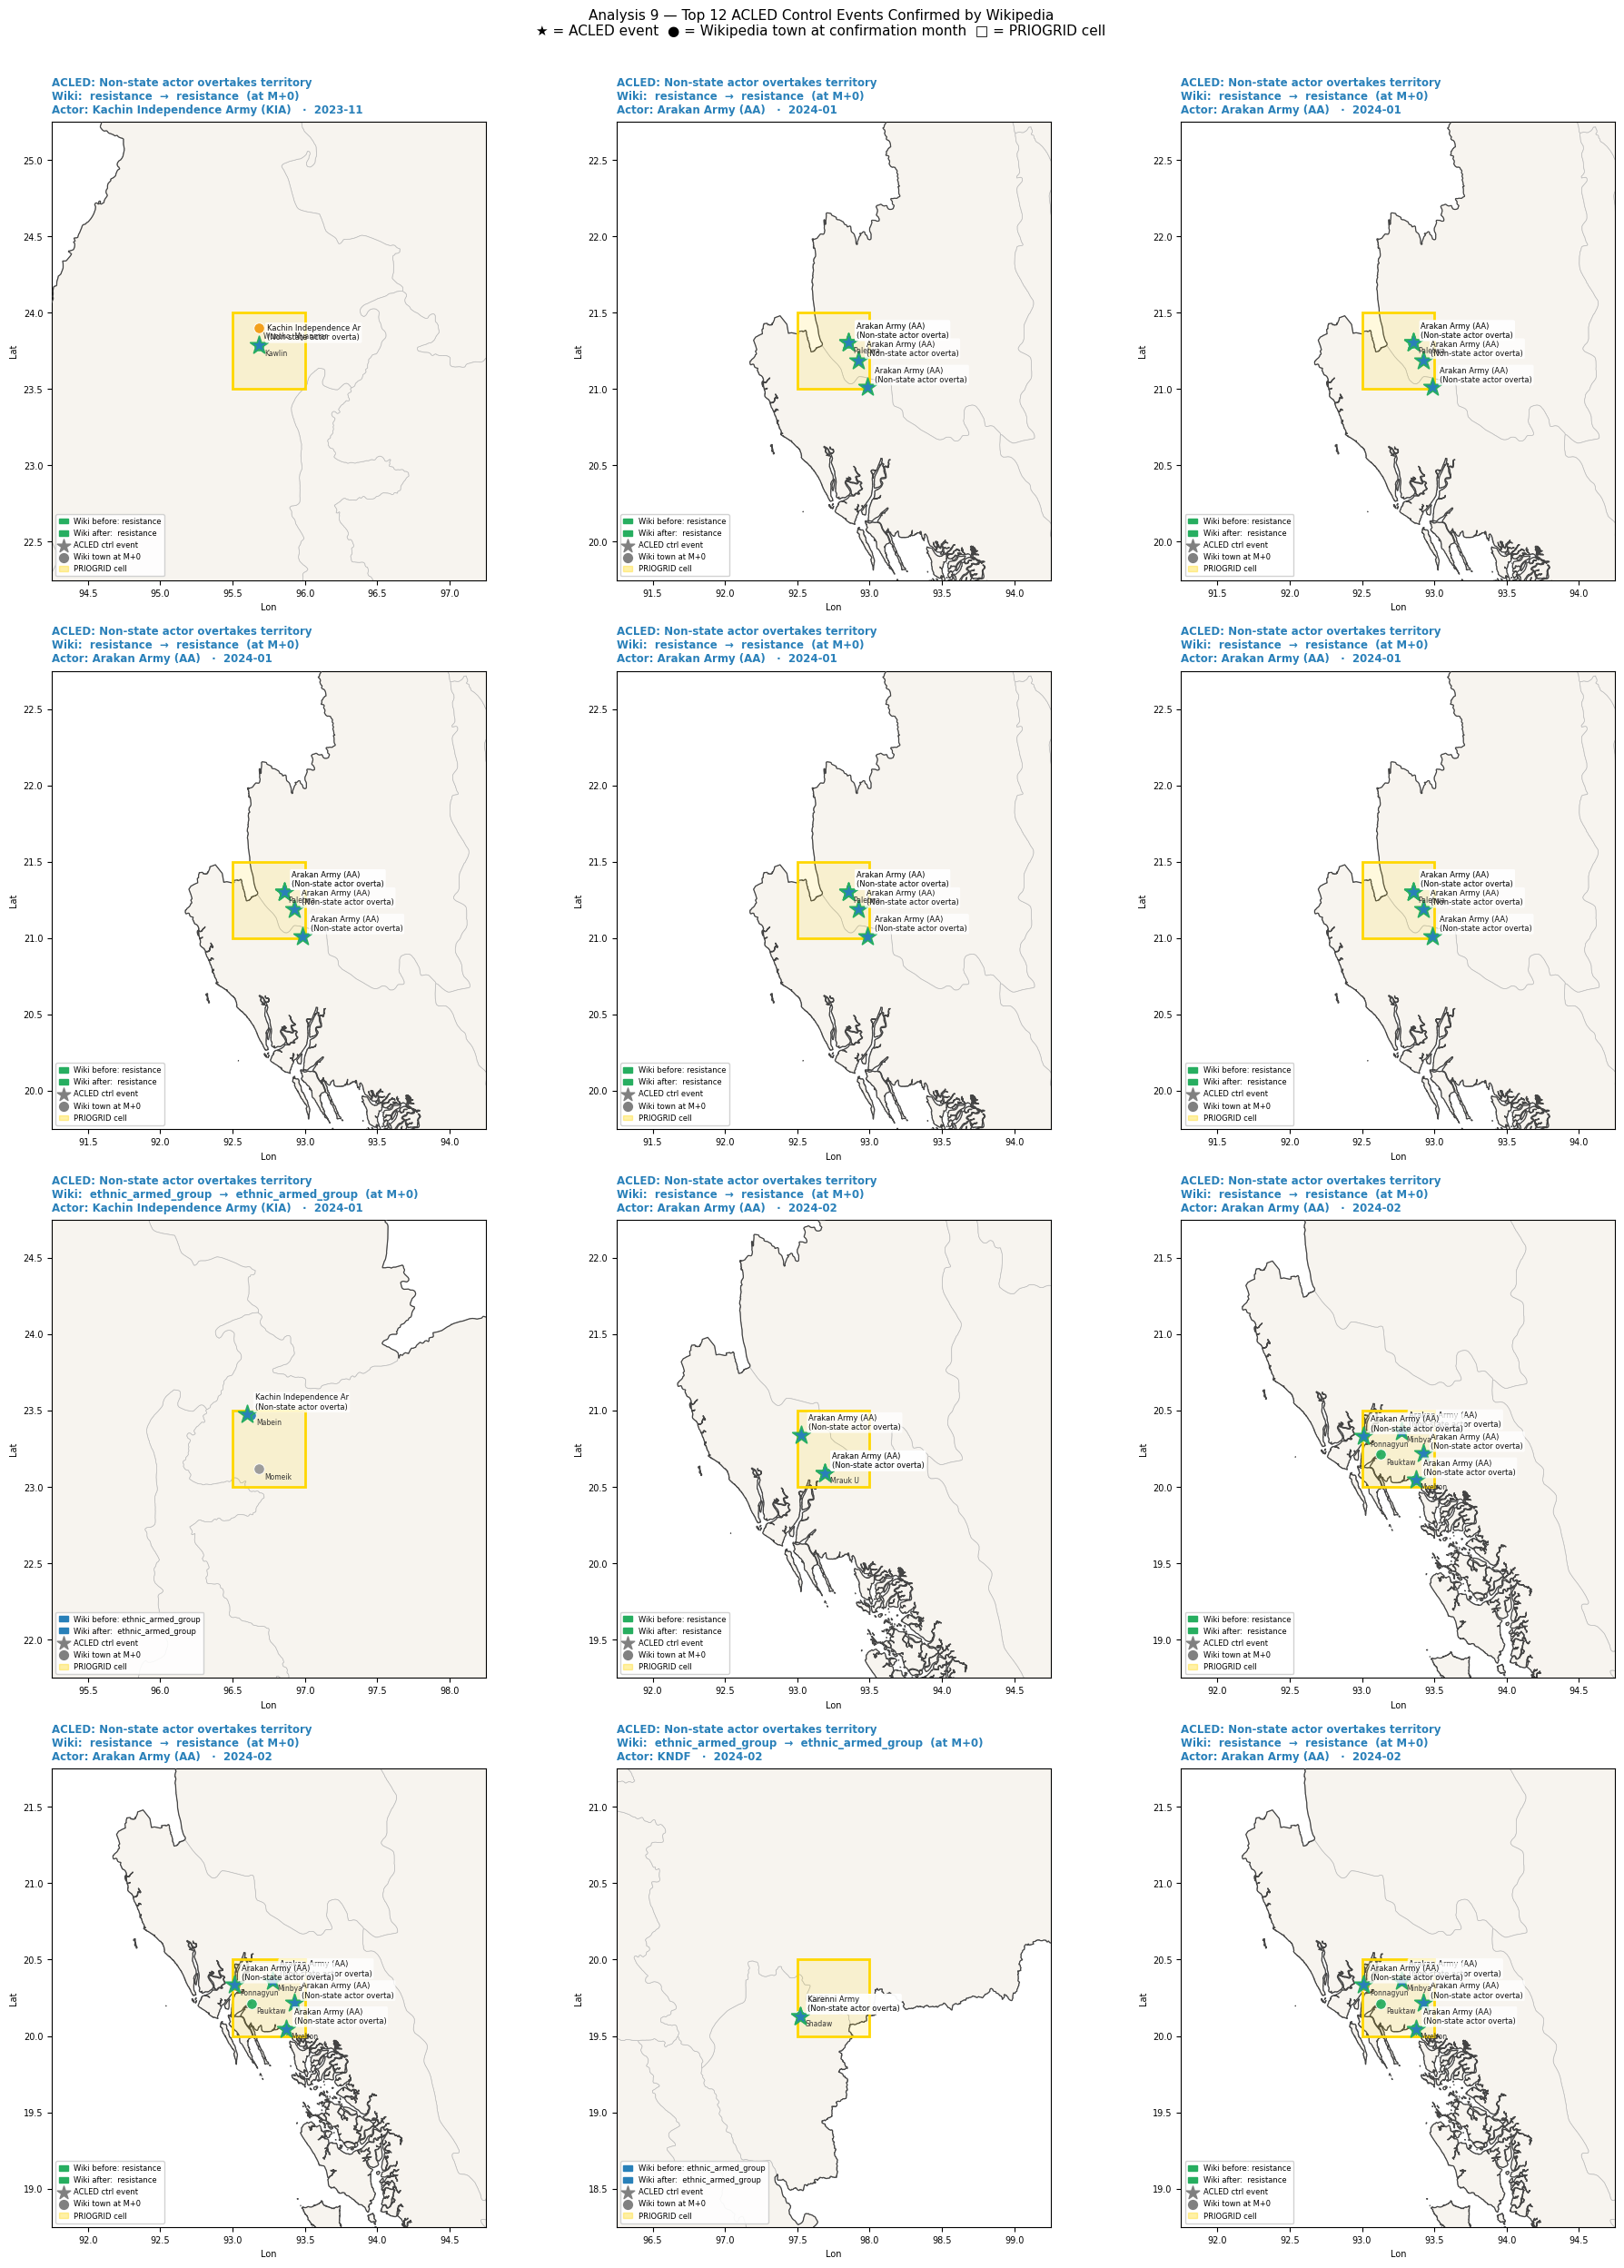

In [21]:
from matplotlib.patches import Rectangle

# confirmed events: wiki was NOT already matching at M, then matched at M+1/2/3
confirmed = fwd_df[fwd_df['any_conf']].reset_index(drop=True)

# pick a grid: show up to 12 (4×3), sorted by confirmation lag then side
confirmed['first_lag'] = confirmed['first_conf_lag']
confirmed = confirmed.sort_values(['first_lag','side','ym']).reset_index(drop=True)
show = confirmed.head(12)

n_rows = (len(show) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(19, n_rows * 6.2))
axes = axes.flatten()

STATUS_COL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}
SIDE_COL = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}

for ax_i, (_, ev) in enumerate(show.iterrows()):
    ax  = axes[ax_i]
    gid = ev['gid'] if 'gid' in fwd_df.columns else None

    # look up gid from fwd_df index
    gid = int(fwd_df.loc[fwd_df.index[ev.name] if hasattr(ev,'name') else ax_i, 'gid'] \
              if 'gid' in fwd_df.columns else ev['priogrid_gid'])
    gid = int(ev['gid']) if 'gid' in ev.index else int(ev['priogrid_gid'])

    ym   = ev['ym']
    side = ev['side']
    lag  = int(ev['first_lag'])

    wiki_before = ev['wiki_at_M']
    wiki_col = 'wiki_at_M' if lag == 0 else f'wiki_at_M{lag}'
    wiki_after  = ev[wiki_col]

    cell_r  = (gid - 1) // 720;  cell_c = (gid - 1) % 720
    lon_min = cell_c * 0.5 - 180; lat_min = cell_r * 0.5 - 90
    clon = lon_min + 0.25;         clat = lat_min + 0.25
    buf  = 1.5
    xl = (clon - buf, clon + buf); yl = (clat - buf, clat + buf)

    gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#bbbbbb', linewidth=0.5, zorder=1)
    gadm0.boundary.plot(ax=ax, color='#444', linewidth=0.9, zorder=3)
    ax.add_patch(Rectangle((lon_min, lat_min), 0.5, 0.5,
                            linewidth=2, edgecolor='#FFD700',
                            facecolor='#FFD70022', zorder=4))

    # ── ACLED event (the triggering control signal) ───────────────────────────
    acled_ev = acled_full[
        (acled_full['priogrid_gid'] == gid) &
        (acled_full['year_month'] == ym) &
        (acled_full['is_control_signal']) &
        (acled_full['side'] == side)
    ]
    for _, aev in acled_ev.iterrows():
        ax.scatter(aev['longitude'], aev['latitude'],
                   c=SIDE_COL.get(side, '#999'), s=220, marker='*',
                   linewidths=1.2, edgecolors='#27AE60', zorder=7)
        ax.annotate(f"{aev['actor_group'][:22]}\n({aev['sub_event_type'][:22]})",
                    (aev['longitude'], aev['latitude']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=6, color='#111', zorder=8,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.78, ec='none'))

    # ── Wikipedia towns at M+lag (after confirmation) ─────────────────────────
    wiki_after_towns = wiki[
        (wiki['priogrid_gid'] == gid) &
        (wiki['year_month'] == str(pd.Period(ym,'M') + lag))
    ]
    for _, tw in wiki_after_towns.iterrows():
        ax.scatter(tw['lon'], tw['lat'],
                   c=STATUS_COL.get(tw['control_status'], '#999'),
                   s=70, marker='o', linewidths=0.7,
                   edgecolors='white', zorder=6, alpha=0.95)
        ax.annotate(tw['location_name'][:18],
                    (tw['lon'], tw['lat']),
                    textcoords='offset points', xytext=(4, -8),
                    fontsize=5.5, color='#333', zorder=8)

    ax.set_xlim(*xl); ax.set_ylim(*yl)
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Lon', fontsize=7); ax.set_ylabel('Lat', fontsize=7)

    before_str = wiki_before if wiki_before else 'no data'
    after_str  = wiki_after  if wiki_after  else 'no data'
    side_col   = SIDE_COL[side]
    top_actor  = ev['actor_group']

    title_lines = [
        f"ACLED: {ev['sub_event_type']}",
        f"Wiki:  {before_str}  →  {after_str}  (at M+{lag})",
        f"Actor: {top_actor[:32]}   ·  {ym}",
    ]
    ax.set_title('\n'.join(title_lines), fontsize=8.5, pad=7,
                 color=side_col, fontweight='bold', loc='left')

    leg_els = [
        mpatches.Patch(color=STATUS_COL.get(before_str, '#999'),
                       label=f"Wiki before: {before_str}"),
        mpatches.Patch(color=STATUS_COL.get(after_str, '#999'),
                       label=f"Wiki after:  {after_str}"),
        plt.scatter([], [], c='grey', s=120, marker='*', label='ACLED ctrl event'),
        plt.scatter([], [], c='grey', s=50,  marker='o', label=f'Wiki town at M+{lag}'),
        mpatches.Patch(facecolor='#FFD700', alpha=0.35, edgecolor='#FFD700',
                       label='PRIOGRID cell'),
    ]
    ax.legend(handles=leg_els, fontsize=6, loc='lower left',
              framealpha=0.88, handlelength=1.2)

# hide any unused subplots
for ax_i in range(len(show), len(axes)):
    axes[ax_i].set_visible(False)

plt.suptitle(
    f'Analysis 9 — Top {len(show)} ACLED Control Events Confirmed by Wikipedia\n'
    '★ = ACLED event  ● = Wikipedia town at confirmation month  □ = PRIOGRID cell',
    fontsize=11, y=1.005)
plt.tight_layout()
plt.savefig(FIG / 'analysis9_confirmed_maps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 9b — Where ACLED and Wikipedia Disagree

These are cases where ACLED recorded a territorial control event **and** Wikipedia explicitly showed the **opposing side** in control at the same cell during the M–M+3 window.

20 cases selected from 120 disagreements, prioritised by fatalities (most contested first).

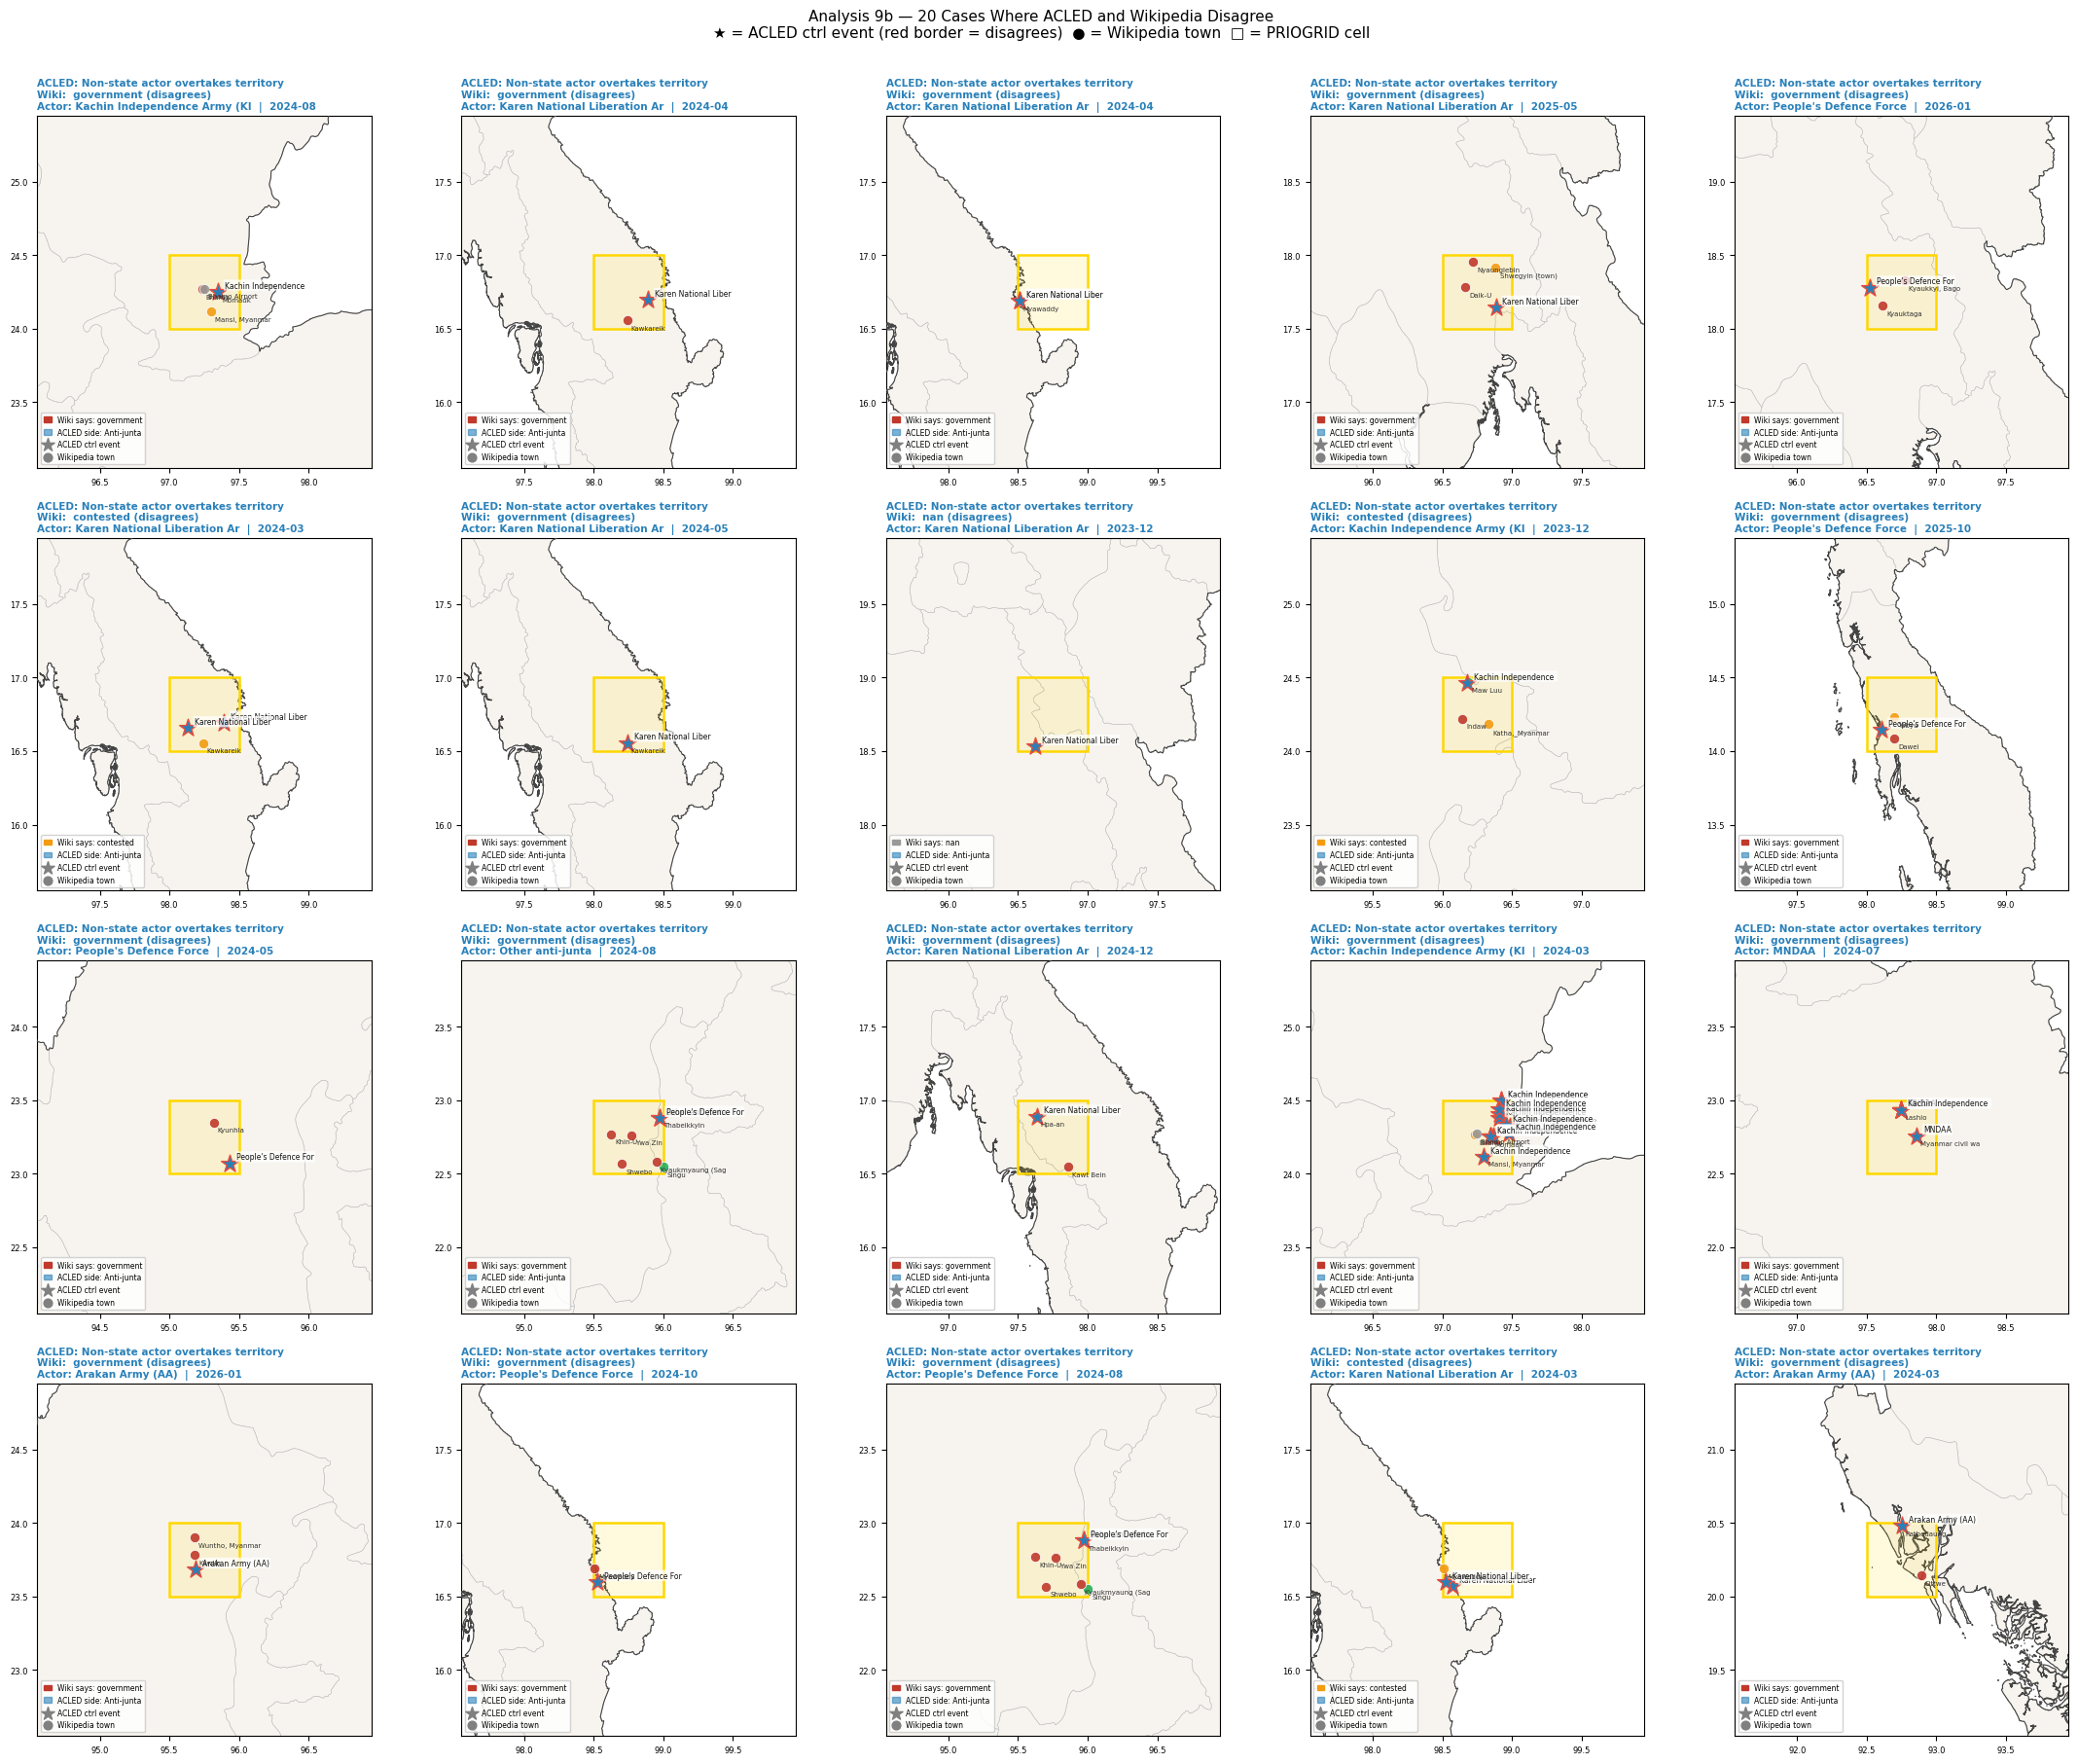

In [22]:
from matplotlib.patches import Rectangle

disagree = (
    fwd_df[fwd_df['never_conf_reason'] == 'Wiki shows opposing side in control']
    .sort_values('fatalities', ascending=False)
    .reset_index(drop=True)
    .head(20)
)

STATUS_COL = {
    'government':         '#c0392b',
    'resistance':         '#27ae60',
    'ethnic_armed_group': '#2980b9',
    'contested':          '#f39c12',
}
SIDE_COL = {'Pro-junta': '#c0392b', 'Anti-junta': '#2980b9'}

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
axes = axes.flatten()

for ax_i, (_, ev) in enumerate(disagree.iterrows()):
    ax   = axes[ax_i]
    gid  = int(ev['gid'])
    ym   = ev['ym']
    side = ev['side']

    cell_r  = (gid - 1) // 720;  cell_c = (gid - 1) % 720
    lon_min = cell_c * 0.5 - 180; lat_min = cell_r * 0.5 - 90
    clon = lon_min + 0.25;         clat = lat_min + 0.25
    buf  = 1.2
    xl = (clon - buf, clon + buf); yl = (clat - buf, clat + buf)

    gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#bbbbbb', linewidth=0.4, zorder=1)
    gadm0.boundary.plot(ax=ax, color='#444', linewidth=0.8, zorder=3)
    ax.add_patch(Rectangle((lon_min, lat_min), 0.5, 0.5,
                            linewidth=1.8, edgecolor='#FFD700',
                            facecolor='#FFD70022', zorder=4))

    # ACLED control signal events at that cell/month
    acled_ev = acled_full[
        (acled_full['priogrid_gid'] == gid) &
        (acled_full['year_month'] == ym) &
        (acled_full['is_control_signal']) &
        (acled_full['side'] == side)
    ]
    for _, aev in acled_ev.iterrows():
        ax.scatter(aev['longitude'], aev['latitude'],
                   c=SIDE_COL.get(side, '#999'), s=180, marker='*',
                   linewidths=1.0, edgecolors='#E74C3C', zorder=7)
        ax.annotate(aev['actor_group'][:20],
                    (aev['longitude'], aev['latitude']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=5.5, color='#111', zorder=8,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75, ec='none'))

    # Wikipedia towns at event month — showing the opposing status
    wiki_towns = wiki[
        (wiki['priogrid_gid'] == gid) &
        (wiki['year_month'] == ym)
    ]
    for _, tw in wiki_towns.iterrows():
        ax.scatter(tw['lon'], tw['lat'],
                   c=STATUS_COL.get(tw['control_status'], '#999'),
                   s=55, marker='o', linewidths=0.6,
                   edgecolors='white', zorder=6, alpha=0.9)
        ax.annotate(tw['location_name'][:16],
                    (tw['lon'], tw['lat']),
                    textcoords='offset points', xytext=(3, -7),
                    fontsize=5, color='#333', zorder=8)

    ax.set_xlim(*xl); ax.set_ylim(*yl)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(''); ax.set_ylabel('')

    wiki_status = ev['wiki_at_M'] or ev['wiki_at_M1'] or ev['wiki_at_M2'] or '?'
    side_col = SIDE_COL[side]
    title_lines = [
        f"ACLED: {ev['sub_event_type']}",
        f"Wiki:  {wiki_status} (disagrees)",
        f"Actor: {ev['actor_group'][:28]}  |  {ym}",
    ]
    ax.set_title('\n'.join(title_lines), fontsize=7.5, pad=5,
                 color=side_col, fontweight='bold', loc='left')

    leg_els = [
        mpatches.Patch(color=STATUS_COL.get(wiki_status, '#999'),
                       label=f'Wiki says: {wiki_status}'),
        mpatches.Patch(color=SIDE_COL[side], alpha=0.6,
                       label=f'ACLED side: {side}'),
        plt.scatter([], [], c='grey', s=100, marker='*', label='ACLED ctrl event'),
        plt.scatter([], [], c='grey', s=40,  marker='o', label='Wikipedia town'),
    ]
    ax.legend(handles=leg_els, fontsize=5.5, loc='lower left',
              framealpha=0.85, handlelength=1.0)

plt.suptitle(
    'Analysis 9b \u2014 20 Cases Where ACLED and Wikipedia Disagree\n'
    '\u2605 = ACLED ctrl event (red border = disagrees)  \u25cf = Wikipedia town  \u25a1 = PRIOGRID cell',
    fontsize=11, y=1.005)
plt.tight_layout()
plt.savefig(FIG / 'analysis9b_disagreement_maps.png', dpi=150, bbox_inches='tight')
plt.show()
